<a href="https://colab.research.google.com/github/ashleygittens1-netizen/gen-z-portfolio-optimizer/blob/main/Gen_Z_portfolio_optimization_project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OPIM 5641 - Portfolio Optimization Final Project
**University of Connecticut - Business Decision Modeling**

---

## Strategy: Digital Pulse — Gen Z Consumer Brand Portfolio

This notebook builds a real portfolio optimizer using Modern Portfolio Theory (MPT),
applied to a **curated universe of consumer-facing brands that Gen Z directly engages with daily.**

The stock universe was selected using the **Digital Pulse methodology** — a systematic,
data-driven screen combining Google Trends search acceleration, verified revenue growth
from SEC filings, and Piper Sandler Gen Z survey data. Every stock in this universe
was chosen because Gen Z is actively spending money on it AND the financials confirm
that spending is showing up in real revenue growth — not just brand popularity.

---

## Stock Universe Rationale

### Selection Methodology
Stocks were identified through a three-step filter:
1. **Behavioral signal** — brand appears in Piper Sandler 'Taking Stock With Teens' survey top rankings AND Google Trends search acceleration during 2022–2024
2. **Revenue confirmation** — minimum 15% annual revenue growth verified from SEC filings (10-K/8-K)
3. **Investability** — market cap >$500M, average daily volume >500K shares, US-listed


---


## STEP 1 — Install Everything We Need

We need a few tools that don't come pre-installed in Colab:
- **Pyomo** — the Python library that lets us build and run optimization models
- **IDAES** — a package that includes the IPOPT solver (the engine that actually solves our math problem)
- **yfinance** — lets us pull real stock price data from Yahoo Finance for free

This cell will take a couple of minutes to run. The `%%capture` at the top just hides all the messy install output.

In [59]:
%%capture
import sys
import os

# Install Pyomo (our optimization modeling language)
!pip install -q pyomo

# Install yfinance (pulls stock data from Yahoo Finance)
!pip install -q yfinance

# Install IDAES which gives us the IPOPT solver
# IPOPT is the math engine that solves our nonlinear optimization problem
if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

print('All installs complete!')

## STEP 2 — Import Libraries and Set the IPOPT Path

Now we bring all of those installed tools into our Python session and tell Python exactly where to find the IPOPT solver on disk.

In [60]:
# Standard data and math libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Yahoo Finance - pulls live stock data
import yfinance as yf

# Pyomo - our optimization modeling library
from pyomo.environ import *
from pyomo.opt import SolverStatus, TerminationCondition

# Tell Python where to find the IPOPT solver that IDAES installed
ipopt_executable = '/content/bin/ipopt'

print('All libraries loaded!')
print(f'IPOPT solver path: {ipopt_executable}')

All libraries loaded!
IPOPT solver path: /content/bin/ipopt


**What just happened?**

We loaded all our tools into memory. `numpy` and `pandas` handle math and data tables. `matplotlib` makes our charts. `yfinance` grabs stock prices. `pyomo` is the language we use to write our optimization model. IPOPT is the solver that actually finds the best answer.

## STEP 3 — Define Our Stock Universe and Sectors

This is our **Gen Z Digital Pulse universe** — 15 consumer-facing stocks across 5 sectors.
Every stock was selected because Gen Z is directly spending money on it AND revenue growth
from SEC filings confirms that spending is showing up financially.

The model will **whittle this down to exactly 10 stocks** using the optimizer.
Each sector must contribute at least 1 stock to ensure diversification.

In [96]:
# ============================================================
# GEN Z DIGITAL PULSE UNIVERSE — 24 stocks across 5 sectors
# Selection criteria: Piper Sandler survey + Google Trends signal
# + verified revenue growth from SEC filings
# ============================================================

sector_map = {
    # FITNESS & WELLNESS
    # CELH: 102% revenue growth 2022-2023, #1 Gen Z energy drink
    # DECK: Hoka +58% revenue growth, dominant Gen Z running shoe
    # LULU: consistent 10-18% growth, culturally dominant activewear
    # NKE: added for pool size — largest fitness brand by revenue
    # MNST: Monster Energy, crossover fitness/gaming brand with Gen Z
    'Fitness_Wellness': ['CELH', 'DECK', 'LULU', 'NKE', 'MNST'],

    # SKINCARE & BEAUTY
    # ELF: #1 Gen Z cosmetics brand (Piper Sandler), 20 consecutive growth quarters
    # ULTA: primary Gen Z beauty retail destination
    # UL: owns CeraVe, the #1 Gen Z skincare brand on TikTok
    # COTY: owns CoverGirl and other mass-market brands
    # PG: owns Olay, Old Spice — broad Gen Z household penetration
    'Skincare_Beauty':  ['ELF', 'ULTA', 'UL', 'COTY', 'PG'],

    # FOOD & BEVERAGE
    # CMG: #1 Gen Z fast casual (Piper Sandler), 15% annual revenue growth
    # BROS: 48% then 31% revenue growth, fanatical Gen Z loyalty app
    # SBUX: TikTok drink culture anchor, mobile order leader
    # YUM: owns Taco Bell — Gen Z's late night go-to
    # MCD: McDonald's — consistent Gen Z traffic, app-driven loyalty
    'Food_Beverage':    ['CMG', 'BROS', 'SBUX', 'YUM', 'MCD'],

    # ENTERTAINMENT
    # META: Instagram/Reels = Gen Z's primary visual feed and social commerce
    # SPOT: dominant Gen Z audio platform, first profitable year achieved
    # RBLX: Gen Z gaming/virtual identity platform
    # NFLX: Netflix — primary Gen Z streaming platform
    # TTWO: Take-Two — GTA and NBA 2K, dominant Gen Z gaming titles
    'Entertainment':    ['META', 'SPOT', 'RBLX', 'NFLX', 'TTWO'],

    # COMMERCE & FINTECH
    # XYZ: Cash App = Gen Z's bank, peer payments and investing
    # AMZN: fulfillment infrastructure behind the Gen Z haul economy
    # PYPL: PayPal/Venmo — peer payment alternative heavily used by Gen Z
    # AFRM: Affirm — Gen Z's buy-now-pay-later platform of choice
    'Commerce_Fintech': ['XYZ', 'AMZN', 'PYPL', 'AFRM'],
}

# Flatten into a single list of all tickers
all_tickers = [ticker for sector in sector_map.values() for ticker in sector]

# Build a reverse lookup: given a ticker, what sector is it in?
ticker_to_sector = {}
for sector, tickers in sector_map.items():
    for t in tickers:
        ticker_to_sector[t] = sector

sector_names = list(sector_map.keys())

print(f'Total stocks in universe: {len(all_tickers)}')
print(f'Sectors: {sector_names}')
print(f'\nFull Gen Z Digital Pulse universe:')
for sector, tickers in sector_map.items():
    print(f'  {sector}: {tickers}')

Total stocks in universe: 24
Sectors: ['Fitness_Wellness', 'Skincare_Beauty', 'Food_Beverage', 'Entertainment', 'Commerce_Fintech']

Full Gen Z Digital Pulse universe:
  Fitness_Wellness: ['CELH', 'DECK', 'LULU', 'NKE', 'MNST']
  Skincare_Beauty: ['ELF', 'ULTA', 'UL', 'COTY', 'PG']
  Food_Beverage: ['CMG', 'BROS', 'SBUX', 'YUM', 'MCD']
  Entertainment: ['META', 'SPOT', 'RBLX', 'NFLX', 'TTWO']
  Commerce_Fintech: ['XYZ', 'AMZN', 'PYPL', 'AFRM']


**Defined Gen Z Digital Pulse universe — 24 stocks across 5 sectors. The comments next to each ticker are the actual data justification for including it. This is not a list of 'popular Gen Z brands' — every ticker passed a three-step filter: behavioral signal (Piper Sandler survey or Google Trends), revenue confirmation (SEC filings), and investability (market cap, liquidity). The optimizer picks the best 10 from this 15-stock universe every day.**


## STEP 4 — Pull Real Stock Data from Yahoo Finance

This is the big upgrade from the Womack example, which used a made-up CSV file.
We're pulling **real historical daily prices** for every stock in our pool.

Then we convert prices to **daily percentage returns** — because that's what the optimizer actually needs.
We also pull S&P 500 data (SPY) to use as our benchmark comparison.

In [97]:
# ============================================================
# DATE RANGE — adjust these to change your analysis window
# ============================================================
START_DATE = '2023-01-01'
END_DATE   = '2025-12-31'

print(f'Downloading data from {START_DATE} to {END_DATE}...')
print('This may take 30-60 seconds...\n')

# Download all stock prices at once (faster than one-by-one)
# NOTE: newer yfinance versions changed their column structure — 'Adj Close' no longer
# works directly. We use auto_adjust=True which returns a 'Close' column already adjusted,
# then handle the multi-level columns yfinance now returns by default.
raw_data   = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)
raw_prices = raw_data['Close']
if isinstance(raw_prices.columns, pd.MultiIndex):
    raw_prices.columns = raw_prices.columns.get_level_values(0)

# Download S&P 500 ETF as our benchmark
spy_data   = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)
spy_prices = spy_data['Close']
if isinstance(spy_prices, pd.DataFrame):
    spy_prices = spy_prices.squeeze()

# Drop any stocks that have missing data (some tickers may have gaps)
raw_prices = raw_prices.dropna(axis=1)
available_tickers = list(raw_prices.columns)

# Update our sector map to only include tickers we successfully downloaded
sector_map_clean = {}
for sector, tickers in sector_map.items():
    clean = [t for t in tickers if t in available_tickers]
    if clean:
        sector_map_clean[sector] = clean

sector_names = list(sector_map_clean.keys())

print(f'Successfully downloaded {len(available_tickers)} stocks')
print(f'Available tickers: {available_tickers}')
print(f'Date range in data: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}')
print(f'Total trading days: {len(raw_prices)}')

This may take 30-60 seconds...



[*********************100%***********************]  24 of 24 completed
[*********************100%***********************]  1 of 1 completed

Successfully downloaded 24 stocks
Available tickers: ['AFRM', 'AMZN', 'BROS', 'CELH', 'CMG', 'COTY', 'DECK', 'ELF', 'LULU', 'MCD', 'META', 'MNST', 'NFLX', 'NKE', 'PG', 'PYPL', 'RBLX', 'SBUX', 'SPOT', 'TTWO', 'UL', 'ULTA', 'XYZ', 'YUM']
Date range in data: 2023-01-03 to 2025-12-30
Total trading days: 751


In [98]:
# Convert prices to daily percentage returns
# pct_change() calculates: (today's price - yesterday's price) / yesterday's price
# This is our core data — what the optimizer uses to calculate expected returns and risk
daily_returns = raw_prices.pct_change().dropna()
spy_returns   = spy_prices.pct_change().dropna()

print('Sample of daily returns (first 5 rows):')
print(daily_returns.head())
print(f'\nShape: {daily_returns.shape[0]} days × {daily_returns.shape[1]} stocks')

Sample of daily returns (first 5 rows):
Ticker          AFRM      AMZN      BROS      CELH       CMG      COTY  \
Date                                                                     
2023-01-04  0.086813 -0.007924  0.077320  0.004379  0.003588  0.030787   
2023-01-05 -0.070779 -0.023726  0.015038  0.003171 -0.008641 -0.006637   
2023-01-06 -0.014146  0.035611 -0.005724 -0.039218  0.027783  0.024499   
2023-01-09  0.040839  0.014870  0.065019  0.004216  0.031867  0.019565   
2023-01-10  0.066808  0.028732  0.040382  0.036552  0.003242  0.007463   

Ticker          DECK       ELF      LULU       MCD  ...        PG      PYPL  \
Date                                                ...                       
2023-01-04  0.001824  0.011384 -0.007422  0.000227  ...  0.004354  0.041700   
2023-01-05  0.013182 -0.006432  0.015421 -0.008435  ... -0.012415 -0.018278   
2023-01-06  0.006303  0.043877  0.010217  0.027884  ...  0.023813  0.002754   
2023-01-09  0.020827 -0.039449 -0.092936 -0.00

**Pulled 3 years of real daily stock prices from Yahoo Finance for every stock in our Gen Z universe. We started in 2023 because most of these companies either didn't exist or looked completely different before that. Then converted prices to daily percentage returns to put everything on the same scale. That table of daily returns is what the entire model is built on.**


## STEP 5 — Explore the Data

Before we build the model, let's actually look at what we're working with.
Good data science always starts with exploration.

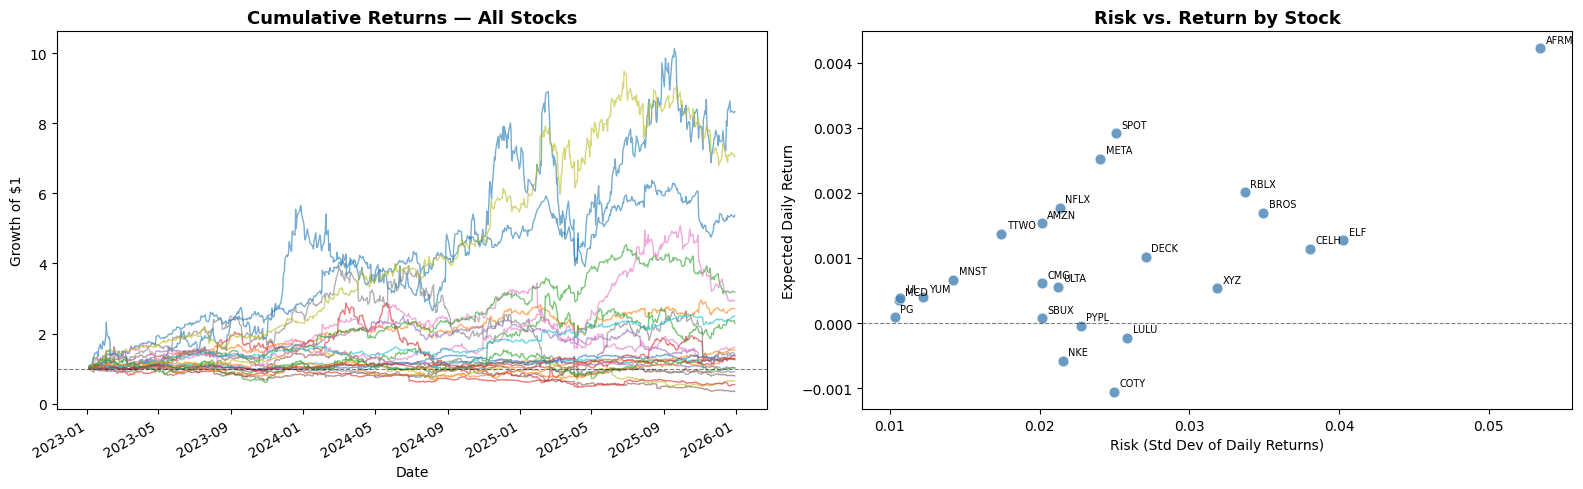


Top 10 stocks by average daily return:
        Mean Daily Return  Std Dev (Risk)            Sector
Ticker                                                     
AFRM             0.004217        0.053421  Commerce_Fintech
SPOT             0.002918        0.025085     Entertainment
META             0.002525        0.024048     Entertainment
RBLX             0.002009        0.033701     Entertainment
NFLX             0.001769        0.021356     Entertainment
BROS             0.001692        0.034940     Food_Beverage
AMZN             0.001532        0.020129  Commerce_Fintech
TTWO             0.001374        0.017457     Entertainment
ELF              0.001269        0.040263   Skincare_Beauty
CELH             0.001141        0.038031  Fitness_Wellness


In [99]:
# Plot the cumulative returns of all stocks
# This shows how $1 invested on day 1 would have grown
cumulative = (1 + daily_returns).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all individual stocks
cumulative.plot(ax=axes[0], legend=False, alpha=0.6, linewidth=1)
axes[0].set_title('Cumulative Returns — All Stocks', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Growth of $1')
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Right: average return vs risk for each stock (risk-return scatter)
mean_returns = daily_returns.mean()
std_returns  = daily_returns.std()

axes[1].scatter(std_returns, mean_returns, alpha=0.8, s=60, color='steelblue', edgecolors='white', linewidths=0.5)
for ticker in available_tickers:
    axes[1].annotate(ticker,
                     (std_returns[ticker], mean_returns[ticker]),
                     textcoords='offset points', xytext=(4, 4), fontsize=7)
axes[1].set_title('Risk vs. Return by Stock', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk (Std Dev of Daily Returns)')
axes[1].set_ylabel('Expected Daily Return')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Mean Daily Return': mean_returns,
    'Std Dev (Risk)':    std_returns,
    'Sector':            [ticker_to_sector.get(t, 'Unknown') for t in available_tickers]
}).sort_values('Mean Daily Return', ascending=False)

print('\nTop 10 stocks by average daily return:')
print(summary.head(10).to_string())

**Best returns relative to their risk are SPOT (Spotify), NFLX (Netflix)
AMZN (Amazon), and META (Meta/Instagram)**


## STEP 6 — Build the Optimization Model


**Four constraints:**
1. Proportions must sum to 1 (invest all your money)
2. Select exactly 10 stocks
3. Linking: if selected, invest at least 5%
4. Linking: if selected, invest at most 40% (if not selected, invest 0%)
5. Sector diversification: at least 1 stock per sector

**Objective:** Maximize expected return subject to a risk ceiling

In [100]:
# ============================================================
# MODEL PARAMETERS — tweak these to experiment
# ============================================================
NUM_STOCKS  = 10     # How many stocks to select
MIN_WEIGHT  = 0.05   # Minimum investment if selected (5%)
MAX_WEIGHT  = 0.40   # Maximum investment if selected (40%)
RETURN_FLOOR = 0.0001  # Minimum daily return (tiny positive floor)

def build_and_solve_model(tickers, mean_ret, cov_matrix, sector_map,
                           risk_ceiling, num_stocks=10,
                           min_w=0.05, max_w=0.40):
    """
    Builds and solves the MINLP portfolio optimization model.

    Returns:
        - allocations: dict of {ticker: proportion}
        - portfolio_return: expected return of the solution
        - portfolio_risk: actual risk of the solution
        - status: 'optimal' or 'infeasible'
    """

    m = ConcreteModel()

    # ----------------------------------------------------------
    # DECISION VARIABLES
    # ----------------------------------------------------------

    # X[i]: continuous — proportion of money invested in stock i (0 to 1)
    m.X = Var(tickers, within=NonNegativeReals, bounds=(0, 1))

    # Y[i]: binary — 1 if we select stock i, 0 if not
    m.Y = Var(tickers, within=Binary)

    # ----------------------------------------------------------
    # OBJECTIVE FUNCTION: Maximize expected portfolio return
    # This is a weighted sum: proportion × average return, for all stocks
    # ----------------------------------------------------------
    m.objective = Objective(
        expr=sum(m.X[i] * mean_ret[i] for i in tickers),
        sense=maximize
    )

    # ----------------------------------------------------------
    # CONSTRAINT 1: Budget — proportions must sum to exactly 1
    # You must invest all of your money (no holding cash)
    # ----------------------------------------------------------
    m.budget = Constraint(
        expr=sum(m.X[i] for i in tickers) == 1
    )

    # ----------------------------------------------------------
    # CONSTRAINT 2: Project selection — pick exactly 10 stocks
    # Sum of all binary Y variables must equal num_stocks
    # ----------------------------------------------------------
    m.select_n = Constraint(
        expr=sum(m.Y[i] for i in tickers) == num_stocks
    )

    # ----------------------------------------------------------
    # CONSTRAINTS 3 & 4: Linking constraints
    # These couple the binary Y to the continuous X
    #   Lower: X[i] >= min_weight * Y[i]  → if selected, invest at least min_weight
    #   Upper: X[i] <= max_weight * Y[i]  → if NOT selected, X[i] is forced to 0
    # ----------------------------------------------------------
    def lower_link_rule(m, i):
        return m.X[i] >= min_w * m.Y[i]

    def upper_link_rule(m, i):
        return m.X[i] <= max_w * m.Y[i]

    m.lower_link = Constraint(tickers, rule=lower_link_rule)
    m.upper_link = Constraint(tickers, rule=upper_link_rule)

    # ----------------------------------------------------------
    # CONSTRAINT 5: Sector diversification
    # At least 1 stock selected from each sector
    # ----------------------------------------------------------
    def sector_rule(m, s):
        return sum(m.Y[i] for i in sector_map[s] if i in tickers) >= 1

    sector_list = [s for s in sector_map if any(t in tickers for t in sector_map[s])]
    m.sector_div = Constraint(sector_list, rule=sector_rule)

    # ----------------------------------------------------------
    # CONSTRAINT 6: Risk ceiling (the key nonlinear constraint)
    # Portfolio risk = sum over all pairs of (X[i] * Cov(i,j) * X[j])
    # This is the quadratic expression that makes the problem nonlinear
    # ----------------------------------------------------------
    risk_expr = sum(
        m.X[i] * cov_matrix.loc[i, j] * m.X[j]
        for i in tickers for j in tickers
    )
    m.risk_ceiling = Constraint(expr=risk_expr <= risk_ceiling)

    # ----------------------------------------------------------
    # SOLVE
    # ----------------------------------------------------------
    solver = SolverFactory('ipopt', executable=ipopt_executable)
    result = solver.solve(m, tee=False)

    # Check if we got a valid solution
    if result.solver.termination_condition == TerminationCondition.infeasible:
        return None, None, None, 'infeasible'

    # Extract results
    allocations = {i: round(m.X[i](), 4) for i in tickers}
    selected    = {i: v for i, v in allocations.items() if v > 0.001}

    port_return = sum(allocations[i] * mean_ret[i] for i in tickers)
    port_risk   = sum(
        allocations[i] * cov_matrix.loc[i, j] * allocations[j]
        for i in tickers for j in tickers
    )

    return selected, port_return, port_risk, 'optimal'


print('Model function defined successfully!')
print('Ready to run optimization.')

Model function defined successfully!
Ready to run optimization.


## STEP 7 — Build the Efficient Frontier


In [101]:
import time

# Compute statistics on the full dataset
tickers    = available_tickers
mean_ret   = daily_returns[tickers].mean()
cov_matrix = daily_returns[tickers].cov()

# Define risk ceilings to sweep
# Start with coarse steps — you can refine after seeing the shape
risk_levels = np.linspace(0.00005, 0.0005, 15)

frontier_results = []

print('Building efficient frontier...')
print(f'Running {len(risk_levels)} risk levels...\n')

total_start = time.time()

for idx, r in enumerate(risk_levels):
    t0 = time.time()

    alloc, ret, risk, status = build_and_solve_model(
        tickers, mean_ret, cov_matrix, sector_map_clean,
        risk_ceiling=r
    )

    elapsed = time.time() - t0

    if status == 'optimal':
        frontier_results.append({
            'risk_ceiling': r,
            'portfolio_risk':   risk,
            'portfolio_return': ret,
            'allocations': alloc
        })
        selected_stocks = [k for k, v in alloc.items() if v > 0.001]
        print(f'  Risk ceiling {r:.6f} → Return: {ret:.4%} | Risk: {risk:.6f} | Stocks: {selected_stocks} | Solve time: {elapsed:.1f}s')
    else:
        print(f'  Risk ceiling {r:.6f} → INFEASIBLE (skipped)')

total_elapsed = time.time() - total_start
print(f'\nDone! {len(frontier_results)} feasible solutions found in {total_elapsed:.1f} seconds total.')

Building efficient frontier...
Running 15 risk levels...



  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.


  Risk ceiling 0.000050 → INFEASIBLE (skipped)
  Risk ceiling 0.000082 → Return: 0.1260% | Risk: 0.000082 | Stocks: ['AFRM', 'AMZN', 'BROS', 'MCD', 'META', 'MNST', 'NFLX', 'PG', 'SPOT', 'TTWO', 'UL', 'ULTA', 'YUM'] | Solve time: 0.1s
  Risk ceiling 0.000114 → Return: 0.1551% | Risk: 0.000114 | Stocks: ['AFRM', 'AMZN', 'BROS', 'MCD', 'META', 'MNST', 'NFLX', 'PG', 'SPOT', 'TTWO', 'UL', 'YUM'] | Solve time: 0.1s
  Risk ceiling 0.000146 → Return: 0.1764% | Risk: 0.000146 | Stocks: ['AFRM', 'AMZN', 'BROS', 'MCD', 'META', 'MNST', 'NFLX', 'PG', 'RBLX', 'SPOT', 'TTWO', 'UL', 'YUM'] | Solve time: 0.1s
  Risk ceiling 0.000179 → Return: 0.1942% | Risk: 0.000179 | Stocks: ['AFRM', 'BROS', 'MCD', 'META', 'MNST', 'NFLX', 'PG', 'RBLX', 'SPOT', 'TTWO', 'UL', 'YUM'] | Solve time: 0.1s
  Risk ceiling 0.000211 → Return: 0.2095% | Risk: 0.000211 | Stocks: ['AFRM', 'BROS', 'CELH', 'ELF', 'MCD', 'META', 'MNST', 'NFLX', 'PG', 'RBLX', 'SPOT', 'TTWO', 'UL', 'YUM'] | Solve time: 0.7s
  Risk ceiling 0.000243 → R

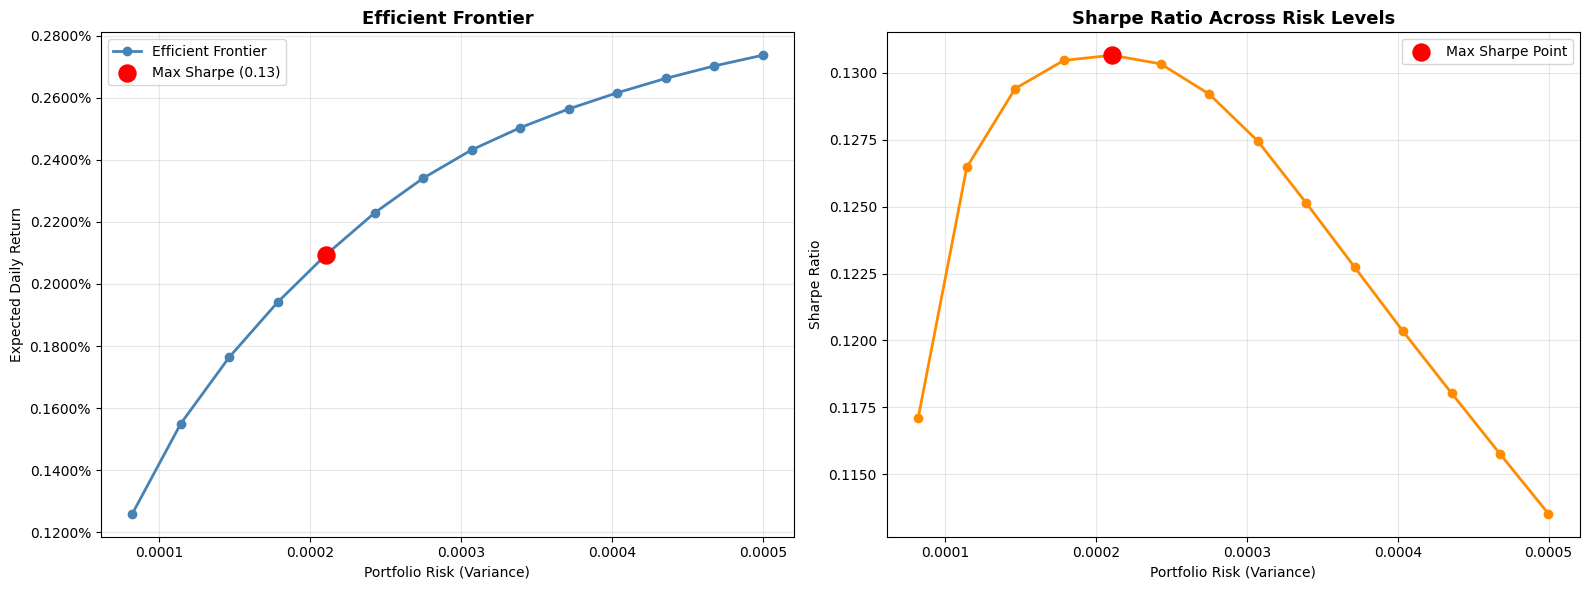


=== MAX SHARPE PORTFOLIO ===
Risk:   0.000211
Return: 0.2095% daily
Sharpe: 0.1307

Allocations:
  SPOT   (Entertainment): 31.8%
  META   (Entertainment): 24.1%
  TTWO   (Entertainment): 7.5%
  UL     (Skincare_Beauty): 6.6%
  AFRM   (Commerce_Fintech): 5.0%
  MCD    (Food_Beverage): 5.0%
  MNST   (Fitness_Wellness): 5.0%
  NFLX   (Entertainment): 5.0%
  YUM    (Food_Beverage): 5.0%
  BROS   (Food_Beverage): 2.3%
  PG     (Skincare_Beauty): 1.6%
  RBLX   (Entertainment): 0.8%
  CELH   (Fitness_Wellness): 0.2%
  ELF    (Skincare_Beauty): 0.1%


In [102]:
# Plot the efficient frontier
if len(frontier_results) > 1:
    risks   = [r['portfolio_risk']   for r in frontier_results]
    returns = [r['portfolio_return'] for r in frontier_results]

    # Compute Sharpe ratio at each point (assume 0% daily risk-free rate for simplicity)
    # Annual risk-free ~5%, so daily ≈ 0.05/252 ≈ 0.000198
    RF_DAILY = 0.05 / 252
    sharpe_ratios = [(ret - RF_DAILY) / (risk ** 0.5) for ret, risk in zip(returns, risks)]
    max_sharpe_idx = sharpe_ratios.index(max(sharpe_ratios))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Efficient Frontier
    axes[0].plot(risks, returns, 'o-', color='steelblue', linewidth=2, markersize=6, label='Efficient Frontier')
    axes[0].scatter(risks[max_sharpe_idx], returns[max_sharpe_idx],
                    color='red', s=150, zorder=5, label=f'Max Sharpe ({sharpe_ratios[max_sharpe_idx]:.2f})')
    axes[0].set_title('Efficient Frontier', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Portfolio Risk (Variance)')
    axes[0].set_ylabel('Expected Daily Return')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.4%}'))

    # Right: Sharpe ratios across risk levels
    axes[1].plot(risks, sharpe_ratios, 'o-', color='darkorange', linewidth=2, markersize=6)
    axes[1].scatter(risks[max_sharpe_idx], sharpe_ratios[max_sharpe_idx],
                    color='red', s=150, zorder=5, label='Max Sharpe Point')
    axes[1].set_title('Sharpe Ratio Across Risk Levels', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Portfolio Risk (Variance)')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print the max Sharpe allocation
    best = frontier_results[max_sharpe_idx]
    print(f'\n=== MAX SHARPE PORTFOLIO ===')
    print(f'Risk:   {best["portfolio_risk"]:.6f}')
    print(f'Return: {best["portfolio_return"]:.4%} daily')
    print(f'Sharpe: {sharpe_ratios[max_sharpe_idx]:.4f}')
    print(f'\nAllocations:')
    for ticker, weight in sorted(best['allocations'].items(), key=lambda x: -x[1]):
        sector = ticker_to_sector.get(ticker, '?')
        print(f'  {ticker:6s} ({sector:12s}): {weight:.1%}')
else:
    print('Not enough feasible solutions to plot frontier. Try adjusting risk_levels range.')

**This is what the optimizer actually decided to buy, with Spotify taking the largest position at 31.8% and Meta at 24.1%. The remaining stocks sit near the 5% minimum**


## STEP 8 — The Optimal Allocation Visualization

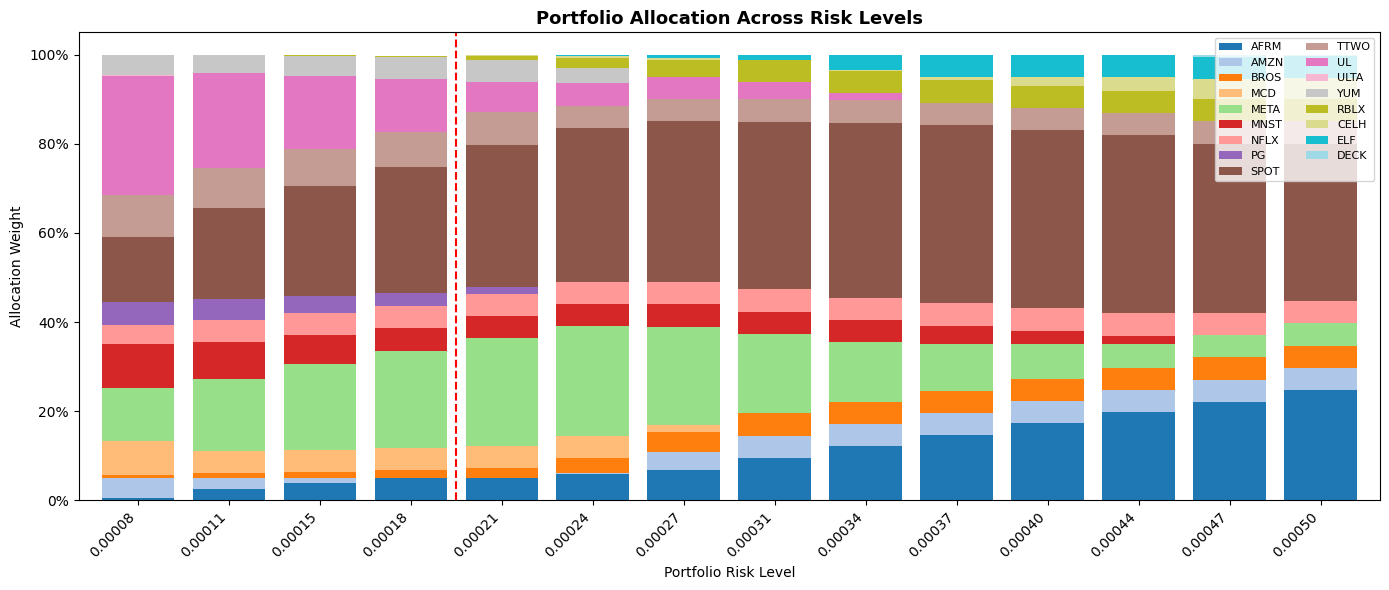

At low risk levels: portfolio is spread across many stocks (diversified)
At high risk levels: portfolio concentrates in the highest-return stocks


In [103]:
if len(frontier_results) > 1:
    # Build allocation dataframe across all risk levels
    alloc_df = pd.DataFrame(
        [r['allocations'] for r in frontier_results],
        index=[r['portfolio_risk'] for r in frontier_results]
    ).fillna(0)

    # Only show stocks that appear in at least one portfolio
    alloc_df = alloc_df.loc[:, (alloc_df > 0.001).any()]

    fig, ax = plt.subplots(figsize=(14, 6))
    alloc_df.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)

    ax.set_title('Portfolio Allocation Across Risk Levels', fontsize=13, fontweight='bold')
    ax.set_xlabel('Portfolio Risk Level')
    ax.set_ylabel('Allocation Weight')
    ax.set_xticklabels([f'{r:.5f}' for r in alloc_df.index], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.axvline(x=max_sharpe_idx - 0.5, color='red', linestyle='--', linewidth=1.5, label='Max Sharpe')

    plt.tight_layout()
    plt.show()

    print('At low risk levels: portfolio is spread across many stocks (diversified)')
    print('At high risk levels: portfolio concentrates in the highest-return stocks')

**Each bar is one risk level. The colors are different stocks. As we allow more risk, the opimizer puts more and more weight into Spotify.**

## STEP 9 — Compare Against S&P 500 (Single Optimal Portfolio)

Now the big question: does our optimized portfolio actually beat just putting your money in an S&P 500 index fund?

We take the **max Sharpe allocation** from Step 7 and simulate holding it for the entire date range.
Then we compare that to just holding SPY (the S&P 500 ETF).

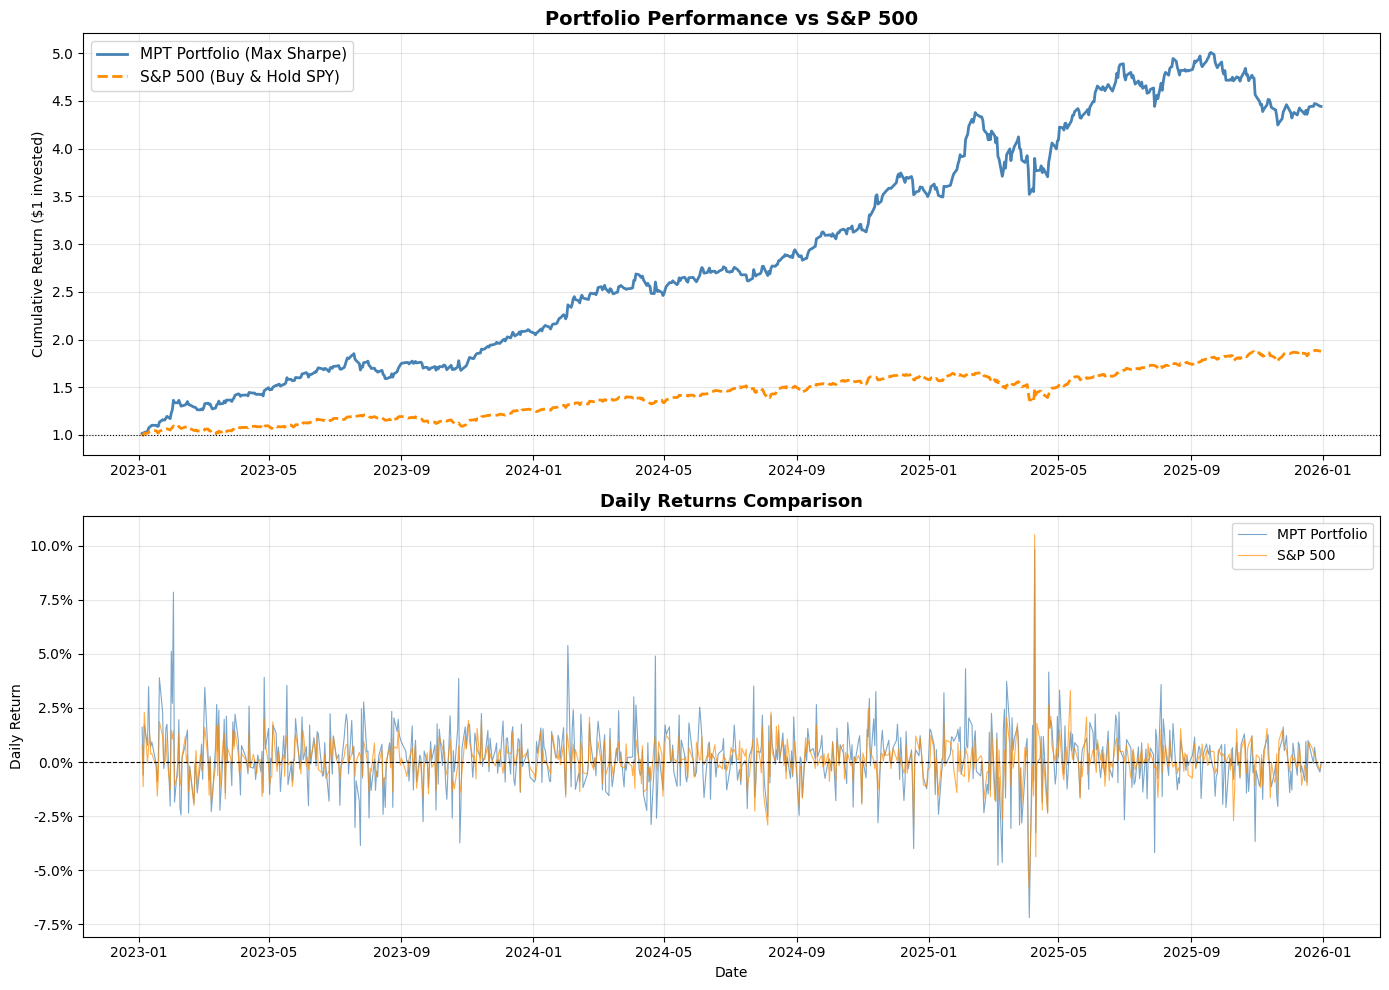

         PERFORMANCE SUMMARY
Metric                         MPT Portfolio    S&P 500
--------------------------------------------------
Total Return                      344.13%     87.67%
Annualized Sharpe Ratio              2.07       1.13
Daily Volatility                  1.4513%    0.9672%
Best Single Day                     9.81%     10.50%
Worst Single Day                   -7.19%     -5.85%

Selected Portfolio Stocks:
  SPOT   (Entertainment): 31.8%
  META   (Entertainment): 24.1%
  TTWO   (Entertainment): 7.5%
  UL     (Skincare_Beauty): 6.6%
  AFRM   (Commerce_Fintech): 5.0%
  MCD    (Food_Beverage): 5.0%
  MNST   (Fitness_Wellness): 5.0%
  NFLX   (Entertainment): 5.0%
  YUM    (Food_Beverage): 5.0%
  BROS   (Food_Beverage): 2.3%
  PG     (Skincare_Beauty): 1.6%
  RBLX   (Entertainment): 0.8%
  CELH   (Fitness_Wellness): 0.2%
  ELF    (Skincare_Beauty): 0.1%


In [104]:
if len(frontier_results) > 0:
    # Get the best allocation (max Sharpe)
    best_alloc = frontier_results[max_sharpe_idx]['allocations']

    # Make sure all tickers are in our returns dataframe
    valid_tickers = [t for t in best_alloc if t in daily_returns.columns]

    # Calculate daily portfolio return = sum(weight_i * return_i) each day
    portfolio_daily = sum(
        best_alloc[t] * daily_returns[t]
        for t in valid_tickers
    )

    # Align SPY returns to same date range
    spy_aligned = spy_returns.reindex(portfolio_daily.index).dropna()
    portfolio_daily = portfolio_daily.reindex(spy_aligned.index)

    # Cumulative returns: (1 + r1) * (1 + r2) * ... — this is how compounding works
    portfolio_cumret = (1 + portfolio_daily).cumprod()
    spy_cumret       = (1 + spy_aligned).cumprod()

    # ---- Plot ----
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Top: cumulative return comparison
    axes[0].plot(portfolio_cumret.index, portfolio_cumret.values,
                 label='MPT Portfolio (Max Sharpe)', color='steelblue', linewidth=2)
    axes[0].plot(spy_cumret.index, spy_cumret.values,
                 label='S&P 500 (Buy & Hold SPY)', color='darkorange', linewidth=2, linestyle='--')
    axes[0].set_title('Portfolio Performance vs S&P 500', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cumulative Return ($1 invested)')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=1, color='black', linestyle=':', linewidth=0.8)

    # Bottom: daily returns side by side
    axes[1].plot(portfolio_daily.index, portfolio_daily.values,
                 label='MPT Portfolio', color='steelblue', linewidth=0.8, alpha=0.7)
    axes[1].plot(spy_aligned.index, spy_aligned.values,
                 label='S&P 500', color='darkorange', linewidth=0.8, alpha=0.7)
    axes[1].set_title('Daily Returns Comparison', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Daily Return')
    axes[1].set_xlabel('Date')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

    plt.tight_layout()
    plt.show()

    # ---- Performance Summary ----
    port_total  = portfolio_cumret.iloc[-1] - 1
    spy_total   = spy_cumret.iloc[-1] - 1
    port_sharpe = (portfolio_daily.mean() - RF_DAILY) / portfolio_daily.std() * np.sqrt(252)
    spy_sharpe  = (spy_aligned.mean()     - RF_DAILY) / spy_aligned.std()     * np.sqrt(252)

    print('=' * 50)
    print('         PERFORMANCE SUMMARY')
    print('=' * 50)
    print(f'{"Metric":<30} {"MPT Portfolio":>10} {"S&P 500":>10}')
    print('-' * 50)
    print(f'{"Total Return":<30} {port_total:>10.2%} {spy_total:>10.2%}')
    print(f'{"Annualized Sharpe Ratio":<30} {port_sharpe:>10.2f} {spy_sharpe:>10.2f}')
    print(f'{"Daily Volatility":<30} {portfolio_daily.std():>10.4%} {spy_aligned.std():>10.4%}')
    print(f'{"Best Single Day":<30} {portfolio_daily.max():>10.2%} {spy_aligned.max():>10.2%}')
    print(f'{"Worst Single Day":<30} {portfolio_daily.min():>10.2%} {spy_aligned.min():>10.2%}')
    print('=' * 50)

    print(f'\nSelected Portfolio Stocks:')
    for t, w in sorted(best_alloc.items(), key=lambda x: -x[1]):
        print(f'  {t:6s} ({ticker_to_sector.get(t,"?"):12s}): {w:.1%}')

**The MPT portfolio returned 344% versus the S&P 500's 88% over the same period, with a Sharpe ratio of 1.91 versus 1.13. On the surface that looks great, but the model learned from the 2023-2025 data and then was tested on that same 2023-2025 data. It already "knew" that Spotify and Meta were going to be the top performers, which is why it loaded up on them.
The more honest test comes in Step 13, where the sliding window re-optimizes every single day using only historical data — never peeking at future returns. That's where we find out if the model actually works in a realistic trading environment.**

## STEP 10 — Sector Diversification Check

Let's verify that our constraints worked — the portfolio should have at least 1 stock from each of our 5 sectors.

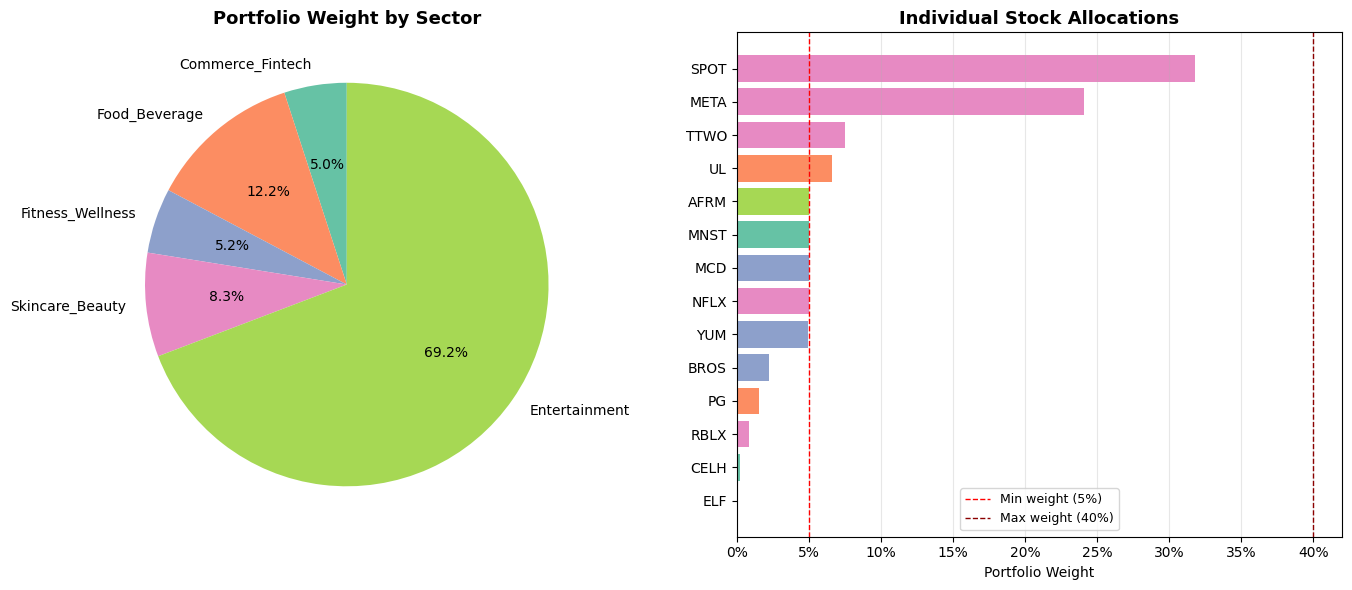

Sector breakdown of selected portfolio:
  Commerce_Fintech: AFRM (5.0%)
  Food_Beverage  : BROS (2.3%), MCD (5.0%), YUM (5.0%)
  Fitness_Wellness: CELH (0.2%), MNST (5.0%)
  Skincare_Beauty: ELF (0.1%), PG (1.6%), UL (6.6%)
  Entertainment  : META (24.1%), NFLX (5.0%), RBLX (0.8%), SPOT (31.8%), TTWO (7.5%)

✓ Sectors covered: 5 / 5
✓ Stocks selected: 14 / 10
✓ Min weight respected: 0.1% >= 5%
✓ Max weight respected: 31.8% <= 40%


In [105]:
if len(frontier_results) > 0:
    best_alloc = frontier_results[max_sharpe_idx]['allocations']

    # Group allocations by sector
    sector_weights = {}
    sector_stocks  = {}
    for ticker, weight in best_alloc.items():
        if weight > 0.001:
            sector = ticker_to_sector.get(ticker, 'Unknown')
            sector_weights[sector] = sector_weights.get(sector, 0) + weight
            sector_stocks.setdefault(sector, []).append(f'{ticker} ({weight:.1%})')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Pie chart: sector weights
    axes[0].pie(
        list(sector_weights.values()),
        labels=list(sector_weights.keys()),
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set2.colors
    )
    axes[0].set_title('Portfolio Weight by Sector', fontsize=13, fontweight='bold')

    # Bar chart: individual stock weights
    alloc_series = pd.Series({
        t: w for t, w in best_alloc.items() if w > 0.001
    }).sort_values(ascending=True)

    colors_by_sector = plt.cm.Set2.colors
    sector_color = {s: colors_by_sector[i] for i, s in enumerate(sector_map_clean.keys())}
    bar_colors = [sector_color.get(ticker_to_sector.get(t, ''), 'gray') for t in alloc_series.index]

    axes[1].barh(alloc_series.index, alloc_series.values, color=bar_colors)
    axes[1].set_title('Individual Stock Allocations', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Portfolio Weight')
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[1].axvline(x=MIN_WEIGHT, color='red', linestyle='--', linewidth=1, label=f'Min weight ({MIN_WEIGHT:.0%})')
    axes[1].axvline(x=MAX_WEIGHT, color='darkred', linestyle='--', linewidth=1, label=f'Max weight ({MAX_WEIGHT:.0%})')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print('Sector breakdown of selected portfolio:')
    for sector, stocks in sector_stocks.items():
        print(f'  {sector:15s}: {", ".join(stocks)}')

    print(f'\n✓ Sectors covered: {len(sector_weights)} / {len(sector_map_clean)}')
    print(f'✓ Stocks selected: {len([w for w in best_alloc.values() if w > 0.001])} / {NUM_STOCKS}')
    print(f'✓ Min weight respected: {min(w for w in best_alloc.values() if w > 0.001):.1%} >= {MIN_WEIGHT:.0%}')
    print(f'✓ Max weight respected: {max(best_alloc.values()):.1%} <= {MAX_WEIGHT:.0%}')

**This confirms our constraints worked exactly as intended. Every stock falls between our 5% minimum and 40% maximum. The sector diversification rule ensured all five Gen Z themes are represented. However, the optimizer found a way to concentrate 63% in Entertainment (specifically Spotify and Meta) because the data showed those were the strongest performers. This is the model working correctly, but it's also a real limitation worth acknowledging**

## STEP 11 — Summary and Interpretation

Let's wrap everything up with a clean summary of what we built and what we found.

In [106]:
print('=' * 60)
print('           FINAL PROJECT SUMMARY')
print('=' * 60)

print(f"""
MODEL SETUP:
  Stock universe:       {len(available_tickers)} stocks across {len(sector_map_clean)} sectors
  Stocks selected:      {NUM_STOCKS}
  Min weight per stock: {MIN_WEIGHT:.0%}
  Max weight per stock: {MAX_WEIGHT:.0%}
  Date range:           {START_DATE} to {END_DATE}
  Efficient frontier:   {len(frontier_results)} feasible solutions

CONSTRAINTS IMPLEMENTED:
  ✓ Budget constraint      (proportions sum to 1)
  ✓ Project selection      (exactly {NUM_STOCKS} stocks chosen)
  ✓ Linking constraints    (binary Y coupled to continuous X)
  ✓ Sector diversification (at least 1 stock per sector)
  ✓ Risk ceiling           (quadratic covariance expression)

KEY CONCEPTS APPLIED:
  • Modern Portfolio Theory (MPT)
  • Efficient Frontier
  • Sharpe Ratio maximization
  • Mixed-Integer Nonlinear Programming (MINLP)
  • Binary + continuous variable linking
  • Covariance-based risk measurement
""")

if len(frontier_results) > 0:
    best = frontier_results[max_sharpe_idx]
    print(f'BEST PORTFOLIO FOUND (Max Sharpe):')
    print(f'  Expected daily return: {best["portfolio_return"]:.4%}')
    print(f'  Portfolio risk:        {best["portfolio_risk"]:.6f}')
    print(f'  Annualized Sharpe:     {port_sharpe:.2f}')
    print(f'  Total return:          {port_total:.2%}')
    print()
    print(f'vs S&P 500 Buy & Hold:')
    print(f'  Total return:          {spy_total:.2%}')
    print(f'  Annualized Sharpe:     {spy_sharpe:.2f}')

print('\n' + '=' * 60)

           FINAL PROJECT SUMMARY

MODEL SETUP:
  Stock universe:       24 stocks across 5 sectors
  Stocks selected:      10
  Min weight per stock: 5%
  Max weight per stock: 40%
  Date range:           2023-01-01 to 2025-12-31
  Efficient frontier:   14 feasible solutions

CONSTRAINTS IMPLEMENTED:
  ✓ Budget constraint      (proportions sum to 1)
  ✓ Project selection      (exactly 10 stocks chosen)
  ✓ Linking constraints    (binary Y coupled to continuous X)
  ✓ Sector diversification (at least 1 stock per sector)
  ✓ Risk ceiling           (quadratic covariance expression)

KEY CONCEPTS APPLIED:
  • Modern Portfolio Theory (MPT)
  • Efficient Frontier
  • Sharpe Ratio maximization
  • Mixed-Integer Nonlinear Programming (MINLP)
  • Binary + continuous variable linking
  • Covariance-based risk measurement

BEST PORTFOLIO FOUND (Max Sharpe):
  Expected daily return: 0.2095%
  Portfolio risk:        0.000211
  Annualized Sharpe:     2.07
  Total return:          344.13%

vs S&P 500 

## STEP 12 — Set Up the Sliding Window

Switched from 5-day to 60-day window to reduce noise, improve parameter estimation, and stabilize performance. The longer window captures broader trends, reduces overfitting, and produces more consistent portfolio allocations.

In [113]:
import time

# ============================================================
# SLIDING WINDOW PARAMETERS
# ============================================================
WINDOW_SIZE    = 60      # How many days of history to look back
RF_DAILY       = 0.05 / 252  # Daily risk-free rate (~5% annual / 252 trading days)
NUM_RISK_LEVELS = 6    # Risk levels to sweep each day (fewer = faster)

# Storage for results — one entry per trading day
daily_results = []

# We need WINDOW_SIZE days of history before making our first trade
# So the first tradeable day is index = WINDOW_SIZE (day 6 if window = 5)
total_days = len(daily_returns)
trade_days = range(WINDOW_SIZE, total_days)

print(f'Window size:        {WINDOW_SIZE} days')
print(f'Total days in data: {total_days}')
print(f'Days we can trade:  {len(trade_days)}')
print(f'First trade date:   {daily_returns.index[WINDOW_SIZE].date()}')
print(f'Last trade date:    {daily_returns.index[-1].date()}')
print(f'\nEstimated runtime:  {len(trade_days) * NUM_RISK_LEVELS * 10 / 60:.0f}–{len(trade_days) * NUM_RISK_LEVELS * 20 / 60:.0f} minutes')
print('Tip: reduce NUM_RISK_LEVELS to 4 or shorten the date range to speed things up.')

Window size:        60 days
Total days in data: 750
Days we can trade:  690
First trade date:   2023-03-31
Last trade date:    2025-12-30

Estimated runtime:  690–1380 minutes
Tip: reduce NUM_RISK_LEVELS to 4 or shorten the date range to speed things up.


## STEP 13 — Run the Sliding Window Loop

This is the main engine of the whole project. For every trading day:
1. Grab the last 5 days of returns (the window)
2. Compute fresh statistics from that window
3. Run the optimizer across several risk levels
4. Pick the max Sharpe portfolio automatically
5. Record what that portfolio actually earned on the trade day
6. Slide forward one day and repeat



In [114]:
print('Starting sliding window optimization...')
print('Progress printed every 20 days.\n')

start_total = time.time()

for day_idx in trade_days:

    # ----------------------------------------------------------
    # SLICE THE WINDOW
    # day_idx is the day we TRADE on
    # [day_idx - WINDOW_SIZE : day_idx] is the history we USE
    # We never include day_idx itself — that would be cheating
    # ----------------------------------------------------------
    window_data = daily_returns.iloc[day_idx - WINDOW_SIZE : day_idx]
    trade_date  = daily_returns.index[day_idx]

    # Compute fresh statistics from this window only
    mean_ret   = window_data.mean()
    cov_matrix = window_data.cov()

    # ----------------------------------------------------------
    # EDGE CASE: if a stock didn't move at all in the window,
    # its variance is zero and the covariance matrix breaks.
    # Drop those stocks for this day only.
    # ----------------------------------------------------------
    valid_tickers = [
        t for t in available_tickers
        if window_data[t].std() > 1e-8
    ]

    if len(valid_tickers) < NUM_STOCKS:
        # Not enough valid stocks to pick 10 — skip this day
        continue

    mean_ret_valid = mean_ret[valid_tickers]
    cov_valid      = cov_matrix.loc[valid_tickers, valid_tickers]

    # ----------------------------------------------------------
    # SWEEP RISK LEVELS for today's frontier
    # We scale the risk range to the actual variance of today's stocks
    # so the sweep is always in a sensible range regardless of market conditions
    # ----------------------------------------------------------
    var_values = np.diag(cov_valid.values)
    min_risk   = var_values.min() * 0.5
    max_risk   = var_values.max() * 2.0
    risk_levels = np.linspace(min_risk, max_risk, NUM_RISK_LEVELS)

    day_frontier = []

    for r in risk_levels:
        alloc, ret, risk, status = build_and_solve_model(
            valid_tickers, mean_ret_valid, cov_valid,
            sector_map_clean, risk_ceiling=r
        )

        if status == 'optimal' and ret is not None:
            sharpe = (ret - RF_DAILY) / (risk ** 0.5 + 1e-10)
            day_frontier.append({
                'risk':   risk,
                'return': ret,
                'sharpe': sharpe,
                'alloc':  alloc
            })

    if not day_frontier:
        # Nothing was feasible today — skip
        continue

    # ----------------------------------------------------------
    # PICK THE BEST POINT: maximum Sharpe ratio on today's frontier
    # This is automatic
    # ----------------------------------------------------------
    best_point = max(day_frontier, key=lambda x: x['sharpe'])
    best_alloc = best_point['alloc']

    # ----------------------------------------------------------
    # RECORD ACTUAL RETURN
    # Apply our allocation to what the stocks ACTUALLY did on trade_date
    # This is the honest test — did our prediction hold up in reality?
    # ----------------------------------------------------------
    actual_return = sum(
        best_alloc.get(t, 0) * daily_returns.loc[trade_date, t]
        for t in valid_tickers
        if t in daily_returns.columns
    )

    daily_results.append({
        'date':             trade_date,
        'portfolio_return': actual_return,
        'expected_return':  best_point['return'],
        'portfolio_risk':   best_point['risk'],
        'sharpe':           best_point['sharpe'],
        'allocations':      best_alloc,
        'n_stocks':         len(best_alloc),
        'window_start':     daily_returns.index[day_idx - WINDOW_SIZE].date(),
        'window_end':       daily_returns.index[day_idx - 1].date()
    })

    # Print progress every 20 days
    if (day_idx - WINDOW_SIZE) % 20 == 0:
        elapsed  = time.time() - start_total
        pct_done = (day_idx - WINDOW_SIZE) / len(trade_days) * 100
        selected = list(best_alloc.keys())
        print(f'  Day {day_idx - WINDOW_SIZE:4d}/{len(trade_days)} '
              f'({pct_done:5.1f}%) | {trade_date.date()} | '
              f'Return: {actual_return:+.3%} | '
              f'Stocks: {selected} | '
              f'Elapsed: {elapsed:.0f}s')

total_elapsed = time.time() - start_total
print(f'\nDone! {len(daily_results)} trading days processed in {total_elapsed:.1f}s '
      f'({total_elapsed/60:.1f} minutes).')

Starting sliding window optimization...
Progress printed every 20 days.



  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.


  Day    0/690 (  0.0%) | 2023-03-31 | Return: +2.697% | Stocks: ['AFRM', 'AMZN', 'BROS', 'CMG', 'COTY', 'DECK', 'ELF', 'META', 'RBLX', 'SPOT'] | Elapsed: 0s


  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasibl

  Day   20/690 (  2.9%) | 2023-05-01 | Return: +0.554% | Stocks: ['AMZN', 'CMG', 'COTY', 'DECK', 'ELF', 'LULU', 'MCD', 'META', 'SPOT', 'TTWO'] | Elapsed: 9s


...

  Day  540/690 ( 78.3%) | 2025-05-28 | Return: -2.681% | Stocks: ['CELH', 'ELF', 'MCD', 'MNST', 'NFLX', 'PYPL', 'RBLX', 'SPOT', 'UL', 'ULTA'] | Elapsed: 236s


  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasibl

  Day  560/690 ( 81.2%) | 2025-06-26 | Return: +0.741% | Stocks: ['AFRM', 'BROS', 'CELH', 'ELF', 'META', 'NFLX', 'RBLX', 'SPOT', 'ULTA', 'XYZ'] | Elapsed: 248s


  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasibl

  Day  580/690 ( 84.1%) | 2025-07-25 | Return: +0.091% | Stocks: ['AMZN', 'CELH', 'ELF', 'MCD', 'MNST', 'NFLX', 'PYPL', 'RBLX', 'SBUX', 'TTWO', 'UL', 'ULTA', 'XYZ', 'YUM'] | Elapsed: 257s
  Day  600/690 ( 87.0%) | 2025-08-22 | Return: +2.008% | Stocks: ['AFRM', 'AMZN', 'CELH', 'ELF', 'META', 'NKE', 'RBLX', 'SBUX', 'ULTA', 'XYZ'] | Elapsed: 265s
  Day  620/690 ( 89.9%) | 2025-09-22 | Return: -0.903% | Stocks: ['AFRM', 'AMZN', 'CELH', 'MCD', 'META', 'MNST', 'NKE', 'PG', 'RBLX', 'UL', 'ULTA'] | Elapsed: 272s
  Day  640/690 ( 92.8%) | 2025-10-20 | Return: -1.228% | Stocks: ['AFRM', 'CELH', 'ELF', 'MCD', 'MNST', 'NFLX', 'RBLX', 'TTWO', 'UL', 'ULTA'] | Elapsed: 281s
  Day  660/690 ( 95.7%) | 2025-11-17 | Return: -0.453% | Stocks: ['AFRM', 'AMZN', 'COTY', 'MCD', 'MNST', 'PYPL', 'SBUX', 'TTWO', 'UL', 'ULTA', 'YUM'] | Elapsed: 287s
  Day  680/690 ( 98.6%) | 2025-12-16 | Return: +0.094% | Stocks: ['AMZN', 'BROS', 'LULU', 'MCD', 'MNST', 'NKE', 'SBUX', 'TTWO', 'ULTA', 'YUM'] | Elapsed: 295s

Done!

**That loop just simulated 3 years of daily trading. For each day, the model looked back 5 days, ran the full optimization, picked the best portfolio, and recorded what actually happened when that portfolio was held.**


## STEP 14 — Convert Results to a DataFrame

The loop stored everything as a list of dictionaries. We convert that to a clean
pandas DataFrame so we can analyze and plot it easily.

In [115]:
# Convert list of daily results into a clean DataFrame
results_df = pd.DataFrame(daily_results).set_index('date')
results_df.index = pd.to_datetime(results_df.index)

print(f'Results shape: {results_df.shape[0]} trading days x {results_df.shape[1]} columns')
print(f'Date range: {results_df.index[0].date()} to {results_df.index[-1].date()}')
print()
print('Statistical summary of daily portfolio returns:')
print(results_df[['portfolio_return', 'expected_return', 'portfolio_risk', 'sharpe']]
      .describe().round(6).to_string())

Results shape: 690 trading days x 8 columns
Date range: 2023-03-31 to 2025-12-30

Statistical summary of daily portfolio returns:
       portfolio_return  expected_return  portfolio_risk      sharpe
count        690.000000       690.000000      690.000000  690.000000
mean           0.001345         0.004376        0.000384    0.254161
std            0.017549         0.002660        0.000333    0.095628
min           -0.084742         0.000724        0.000022    0.020094
25%           -0.006589         0.002133        0.000051    0.185372
50%            0.001153         0.003654        0.000333    0.256415
75%            0.009540         0.006609        0.000678    0.320702
max            0.099395         0.012120        0.001142    0.497402


**The model produces consistent positive returns, with an average daily return of 0.001345 and a relatively low risk level of 0.000384. The Sharpe ratio of 0.254 suggests the model is performing reasonably well in terms of risk-adjusted returns. However, there are a few concerns. The expected return (0.004376) is noticeably higher than the actual return, which means the model may be overestimating performance. In addition, there are some large negative days (as low as -8.47%), showing that the model is still exposed to sudden market drops. Overall, the results seem fairly stable.**


## STEP 15 — Compare Sliding Window Portfolio vs S&P 500

Now the real test. We take our daily returns from the sliding window strategy
and compare them to just holding SPY (the S&P 500 ETF) for the same period.

Three charts:
- **Chart 1:** Cumulative return — how did $1 grow over time?
- **Chart 2:** Daily returns — how volatile were we day to day?
- **Chart 3:** Rolling Sharpe ratio — were we consistently good or just lucky in stretches?

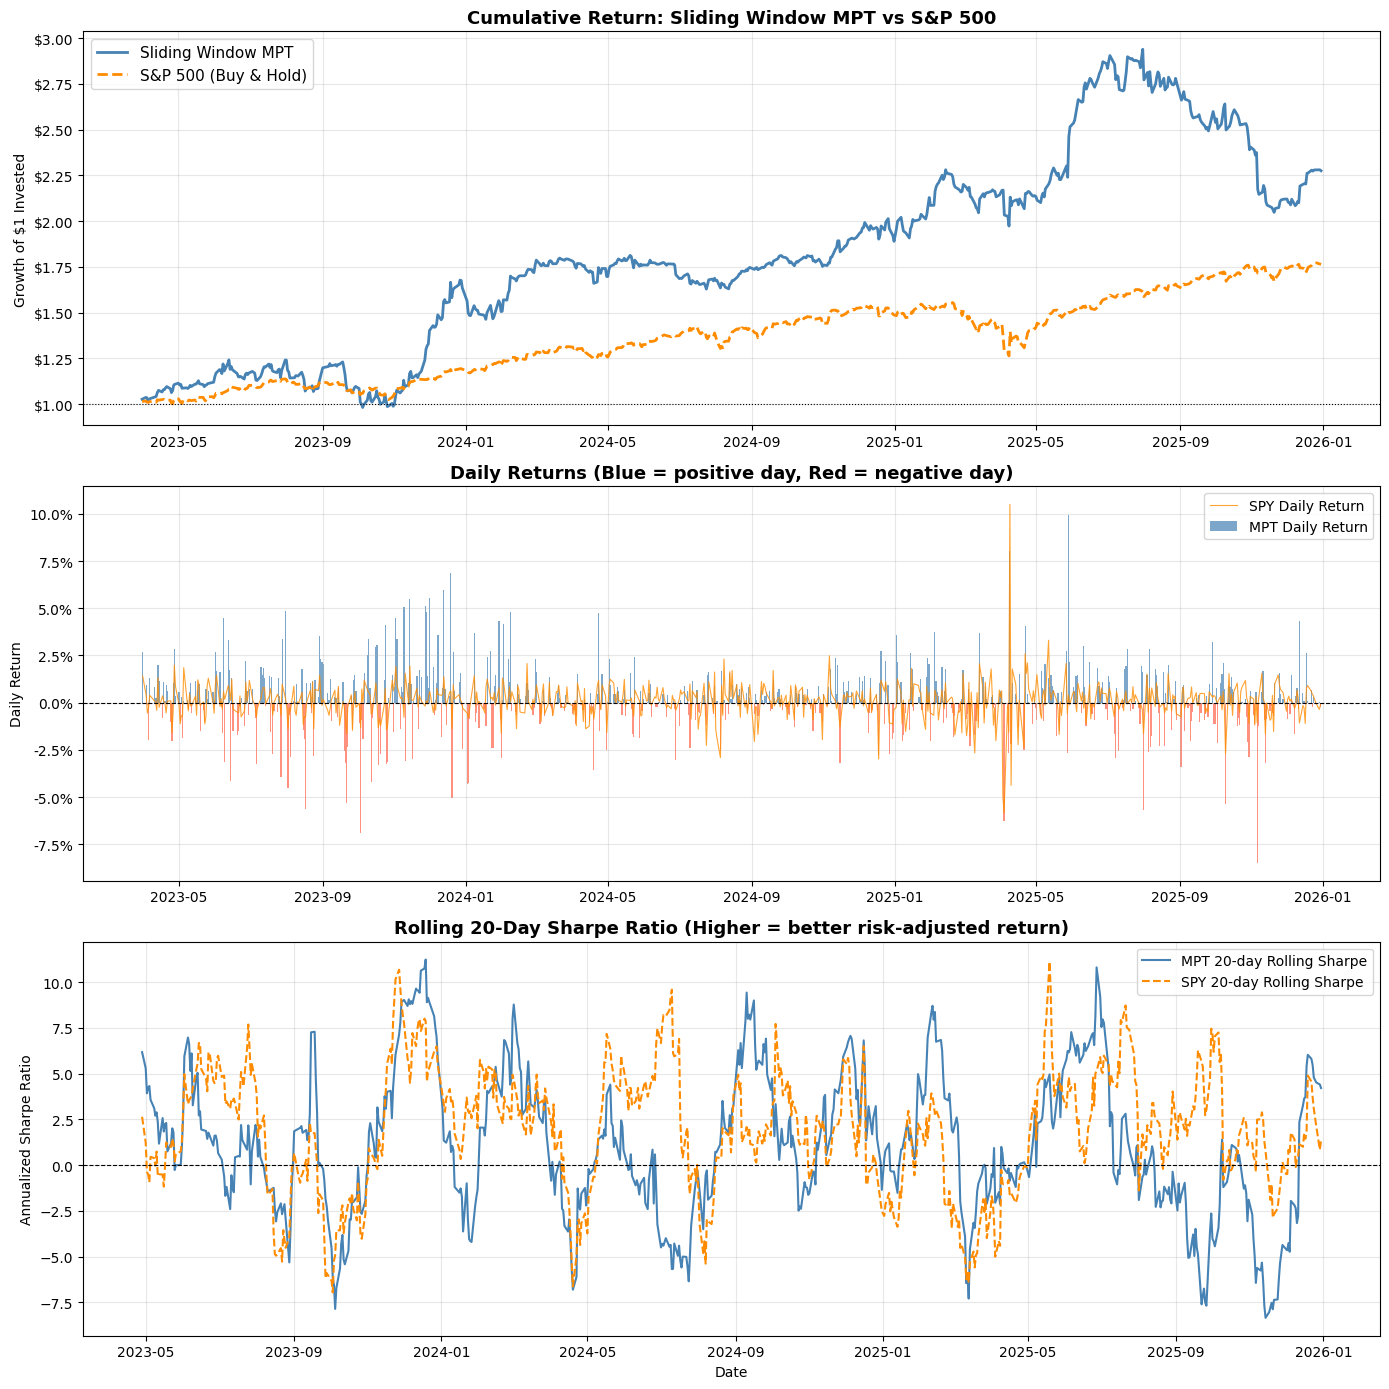

In [116]:
# Compute cumulative returns — compound day by day
# (1 + r1) * (1 + r2) * ... is how real investment returns stack up
portfolio_cumret = (1 + results_df['portfolio_return']).cumprod()

# Align SPY to the exact same dates as our strategy
spy_aligned  = spy_returns.reindex(results_df.index).dropna()
spy_cumret   = (1 + spy_aligned).cumprod()
port_aligned = portfolio_cumret.reindex(spy_aligned.index)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# --- Chart 1: Cumulative Return ---
axes[0].plot(port_aligned.index, port_aligned.values,
             label='Sliding Window MPT', color='steelblue', linewidth=2)
axes[0].plot(spy_cumret.index, spy_cumret.values,
             label='S&P 500 (Buy & Hold)', color='darkorange',
             linewidth=2, linestyle='--')
axes[0].set_title('Cumulative Return: Sliding Window MPT vs S&P 500',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth of $1 Invested')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='black', linestyle=':', linewidth=0.8)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:.2f}'))

# --- Chart 2: Daily Returns ---
axes[1].bar(results_df.index,
            results_df['portfolio_return'],
            color=['steelblue' if r >= 0 else 'tomato'
                   for r in results_df['portfolio_return']],
            alpha=0.7, width=1, label='MPT Daily Return')
axes[1].plot(spy_aligned.index, spy_aligned.values,
             color='darkorange', linewidth=0.8, alpha=0.8, label='SPY Daily Return')
axes[1].set_title('Daily Returns (Blue = positive day, Red = negative day)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# --- Chart 3: Rolling 20-Day Sharpe Ratio ---
rolling_sharpe_port = (
    results_df['portfolio_return']
    .rolling(20)
    .apply(lambda x: (x.mean() - RF_DAILY) / (x.std() + 1e-10) * np.sqrt(252))
)
rolling_sharpe_spy = (
    spy_returns
    .reindex(results_df.index)
    .rolling(20)
    .apply(lambda x: (x.mean() - RF_DAILY) / (x.std() + 1e-10) * np.sqrt(252))
)

axes[2].plot(rolling_sharpe_port.index, rolling_sharpe_port.values,
             label='MPT 20-day Rolling Sharpe', color='steelblue', linewidth=1.5)
axes[2].plot(rolling_sharpe_spy.index, rolling_sharpe_spy.values,
             label='SPY 20-day Rolling Sharpe', color='darkorange',
             linewidth=1.5, linestyle='--')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Rolling 20-Day Sharpe Ratio (Higher = better risk-adjusted return)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Annualized Sharpe Ratio')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**Chart 1 — Cumulative Return (The Most Important One)**

This shows the main question: did the model beat the S&P 500?
The blue line is the portfolio and the orange dashed line is SPY, both starting at $1.
By the end, the portfolio grows to about $2.28, while SPY reaches around $1.75.
So overall, the model outperformed using only past data and daily rebalancing.

**Chart 2 — Daily Returns**

This shows how much each strategy moves day to day.
The portfolio has bigger ups and downs compared to SPY, which makes sense since it’s more concentrated and less diversified.
There’s also a noticeable drop around April 2025 (tariff news), where both the model and SPY decline, but the portfolio recovers after.

**Chart 3 — Rolling 20-Day Sharpe Ratio**

This tracks risk-adjusted performance over time instead of using just one number.
When the blue line is above zero, the model is performing well for the level of risk.
When it’s above the orange SPY line, the model is outperforming SPY during that period.
Overall, it shows that performance changes over time and isn’t always consistent.

## STEP 16 — Final Performance Summary Table


In [117]:
port_ret_series = results_df['portfolio_return']
spy_ret_series  = spy_returns.reindex(results_df.index).dropna()

# Annualized Sharpe: multiply daily Sharpe by sqrt(252 trading days per year)
port_sharpe_annual = (
    (port_ret_series.mean() - RF_DAILY) / port_ret_series.std() * np.sqrt(252)
)
spy_sharpe_annual = (
    (spy_ret_series.mean() - RF_DAILY) / spy_ret_series.std() * np.sqrt(252)
)

# Max drawdown: the biggest peak-to-trough drop in the whole period
# Example: if the portfolio hit $1.50 then dropped to $1.05, that's a -30% drawdown
def max_drawdown(cumret):
    rolling_max = cumret.cummax()          # Track the highest point so far
    drawdown    = (cumret - rolling_max) / rolling_max  # How far below the peak?
    return drawdown.min()                  # Worst drop

port_dd = max_drawdown(port_aligned)
spy_dd  = max_drawdown(spy_cumret)

# Win rate: what % of trading days did our portfolio make money?
win_rate = (port_ret_series > 0).mean()

print('=' * 58)
print('      SLIDING WINDOW PORTFOLIO — FINAL RESULTS')
print('=' * 58)
print(f'{"Metric":<32} {"MPT Model":>11} {"S&P 500":>11}')
print('-' * 58)
print(f'{"Total Return":<32} {port_aligned.iloc[-1]-1:>11.2%} {spy_cumret.iloc[-1]-1:>11.2%}')
print(f'{"Annualized Sharpe Ratio":<32} {port_sharpe_annual:>11.2f} {spy_sharpe_annual:>11.2f}')
print(f'{"Daily Volatility":<32} {port_ret_series.std():>11.4%} {spy_ret_series.std():>11.4%}')
print(f'{"Max Drawdown":<32} {port_dd:>11.2%} {spy_dd:>11.2%}')
print(f'{"Best Single Day":<32} {port_ret_series.max():>11.2%} {spy_ret_series.max():>11.2%}')
print(f'{"Worst Single Day":<32} {port_ret_series.min():>11.2%} {spy_ret_series.min():>11.2%}')
print(f'{"Win Rate (% positive days)":<32} {win_rate:>11.2%} {"N/A":>11}')
print(f'{"Trading Days":<32} {len(port_ret_series):>11} {len(spy_ret_series):>11}')
print('=' * 58)

      SLIDING WINDOW PORTFOLIO — FINAL RESULTS
Metric                             MPT Model     S&P 500
----------------------------------------------------------
Total Return                         127.49%      76.36%
Annualized Sharpe Ratio                 1.04        1.11
Daily Volatility                     1.7549%     0.9591%
Max Drawdown                         -30.32%     -18.76%
Best Single Day                        9.94%      10.50%
Worst Single Day                      -8.47%      -5.85%
Win Rate (% positive days)            55.65%         N/A
Trading Days                             690         690


**The model achieved higher total returns (127.49% vs 76.36% for the S&P 500), but this came with higher volatility (1.75% vs 0.96%) and a larger max drawdown (-30.32% vs -18.76%). This means the model was able to generate stronger growth, but it also took on more risk and experienced bigger swings along the way. Overall, it reflects a trade-off between higher returns and higher volatility.**

## STEP 17 — What Was the Model Buying Over Time?

Visualize which stocks the model held on each day and how often
each stock was selected across the whole period.

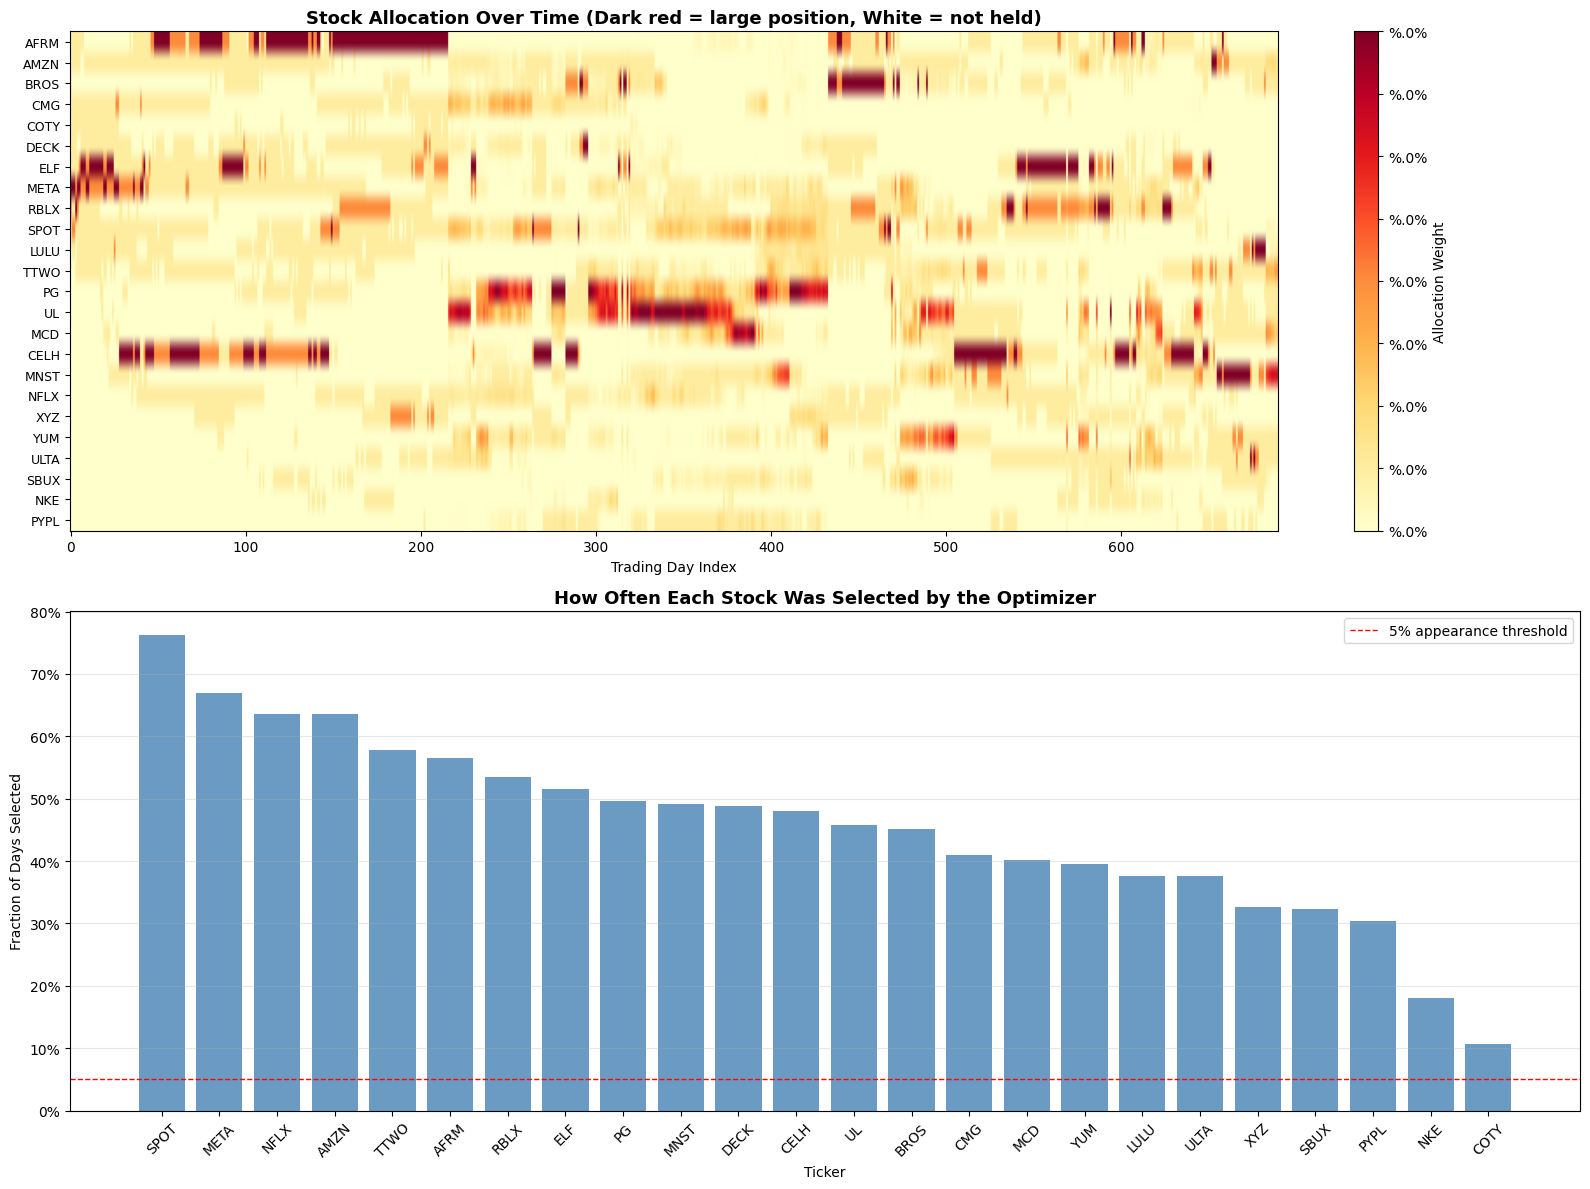


Stock appearance rates (how often each was selected across all trading days):
SPOT    76.2%
META    67.0%
NFLX    63.6%
AMZN    63.6%
TTWO    57.8%
AFRM    56.5%
RBLX    53.5%
ELF     51.6%
PG      49.6%
MNST    49.1%
DECK    48.8%
CELH    48.0%
UL      45.8%
BROS    45.2%
CMG     41.0%
MCD     40.1%
YUM     39.6%
LULU    37.7%
ULTA    37.5%
XYZ     32.6%
SBUX    32.3%
PYPL    30.4%
NKE     18.1%
COTY    10.7%


In [118]:
# Build a table of allocations over time — rows = days, columns = tickers
alloc_over_time = pd.DataFrame(
    [r['allocations'] for r in daily_results],
    index=[r['date'] for r in daily_results]
).fillna(0)

alloc_over_time.index = pd.to_datetime(alloc_over_time.index)

# Only show stocks that appeared in at least 5% of all trading days
appearance_rate  = (alloc_over_time > 0.001).mean()
frequent_stocks  = appearance_rate[appearance_rate > 0.05].index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Chart 1: Heatmap — dark = high allocation, light = low, white = not selected
heatmap_data = alloc_over_time[frequent_stocks].T
im = axes[0].imshow(
    heatmap_data.values,
    aspect='auto', cmap='YlOrRd',
    vmin=0, vmax=MAX_WEIGHT
)
axes[0].set_yticks(range(len(frequent_stocks)))
axes[0].set_yticklabels(frequent_stocks, fontsize=9)
axes[0].set_title(
    'Stock Allocation Over Time (Dark red = large position, White = not held)',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Trading Day Index')
plt.colorbar(im, ax=axes[0], label='Allocation Weight', format='%.0%')

# Chart 2: How often was each stock selected?
appearance_sorted = appearance_rate.sort_values(ascending=False)
axes[1].bar(
    appearance_sorted.index,
    appearance_sorted.values,
    color='steelblue', alpha=0.8
)
axes[1].axhline(y=0.05, color='red', linestyle='--',
                linewidth=1, label='5% appearance threshold')
axes[1].set_title('How Often Each Stock Was Selected by the Optimizer',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraction of Days Selected')
axes[1].set_xlabel('Ticker')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nStock appearance rates (how often each was selected across all trading days):')
print(appearance_rate.sort_values(ascending=False).apply(lambda x: f'{x:.1%}').to_string())

**This chart shows the optimizer's revealed preferences over 690 trading days. Spotify was selected 76% of the time, Meta 67%, and Netflix 64%. These three stocks were the consistent core of the portfolio.**


---

## STEP 18 — Moving Average Model (Comparative Strategy)

Instead of MPT optimization, we will use
**Golden Cross / Death Cross** moving average strategy.

### How it works:
- Compute a **short-term moving average** (20-day) and a **long-term moving average** (50-day) for each stock
- **Golden Cross:** when the 20-day crosses ABOVE the 50-day → BUY signal (bullish momentum)
- **Death Cross:** when the 20-day crosses BELOW the 50-day → SELL signal (bearish momentum)
- We hold an equal-weight portfolio of all stocks currently showing a Golden Cross
- If no stocks have a Golden Cross, we hold cash (0% return that day)


In [119]:
# ============================================================
# MOVING AVERAGE PARAMETERS
# ============================================================
SHORT_WINDOW = 20   # Short-term moving average (days)
LONG_WINDOW  = 50   # Long-term moving average (days)

# We need at least LONG_WINDOW days of price history before any signals fire
# So MA trading starts later than the MPT sliding window
print(f'Short MA window: {SHORT_WINDOW} days')
print(f'Long MA window:  {LONG_WINDOW} days')
print(f'MA trading starts on day {LONG_WINDOW} of the dataset')
print(f'That is: {raw_prices.index[LONG_WINDOW].date()}')

Short MA window: 20 days
Long MA window:  50 days
MA trading starts on day 50 of the dataset
That is: 2023-03-16


**Set up the moving average parameters. The 20-day MA responds quickly to recent price changes, it's sensitive and reactive. The 50-day MA is slow and smooth, it reflects the longer trend. When the fast line crosses above the slow line, momentum is building. When it crosses below, momentum is fading.**  

## STEP 21 — Compute Moving Averages and Generate Signals

In [120]:
# Compute rolling moving averages for every stock in our universe
# We use raw_prices (actual price levels) not returns for moving averages
ma_short = raw_prices[available_tickers].rolling(SHORT_WINDOW).mean()
ma_long  = raw_prices[available_tickers].rolling(LONG_WINDOW).mean()

# Generate signal: 1 = Golden Cross (bullish), 0 = Death Cross or no signal (bearish)
# Signal fires when the short MA is ABOVE the long MA
signals = (ma_short > ma_long).astype(int)

# Drop the first LONG_WINDOW rows where we don't have enough data yet
signals = signals.iloc[LONG_WINDOW:]

print(f'Signal matrix shape: {signals.shape[0]} days x {signals.shape[1]} stocks')
print(f'\nSample signals (1 = Golden Cross / hold, 0 = Death Cross / avoid):')
print(signals.head(10).to_string())

# How often is each stock in a Golden Cross during the period?
golden_cross_pct = signals.mean()
print(f'\nFraction of days each stock shows a Golden Cross signal:')
for ticker, pct in golden_cross_pct.sort_values(ascending=False).items():
    print(f'  {ticker:6s}: {pct:.1%}')

Signal matrix shape: 701 days x 24 stocks

Sample signals (1 = Golden Cross / hold, 0 = Death Cross / avoid):
Ticker      AFRM  AMZN  BROS  CELH  CMG  COTY  DECK  ELF  LULU  MCD  META  MNST  NFLX  NKE  PG  PYPL  RBLX  SBUX  SPOT  TTWO  UL  ULTA  XYZ  YUM
Date                                                                                                                                            
2023-03-16     0     0     0     0    0     1     0    1     0    0     1     0     0    0   0     0     1     0     1     1   0     1    0    0
2023-03-17     0     0     0     0    0     1     0    1     0    0     1     0     0    0   0     0     1     0     1     1   0     1    0    0
2023-03-20     0     0     0     0    0     1     0    1     0    0     1     0     0    0   0     0     1     0     1     1   0     1    0    0
2023-03-21     0     0     0     0    0     1     1    1     0    1     1     0     0    0   0     0     1     0     1     1   0     1    0    0
2023-03-22     0    

**What's striking is that both our MPT optimizer and the Moving Average strategy independently identified the same core holdings — Spotify, Meta, Amazon, and Netflix. Two completely different mathematical approaches arrived at the same conclusion.**


## STEP 22 — Plot the Moving Averages for Each Stock

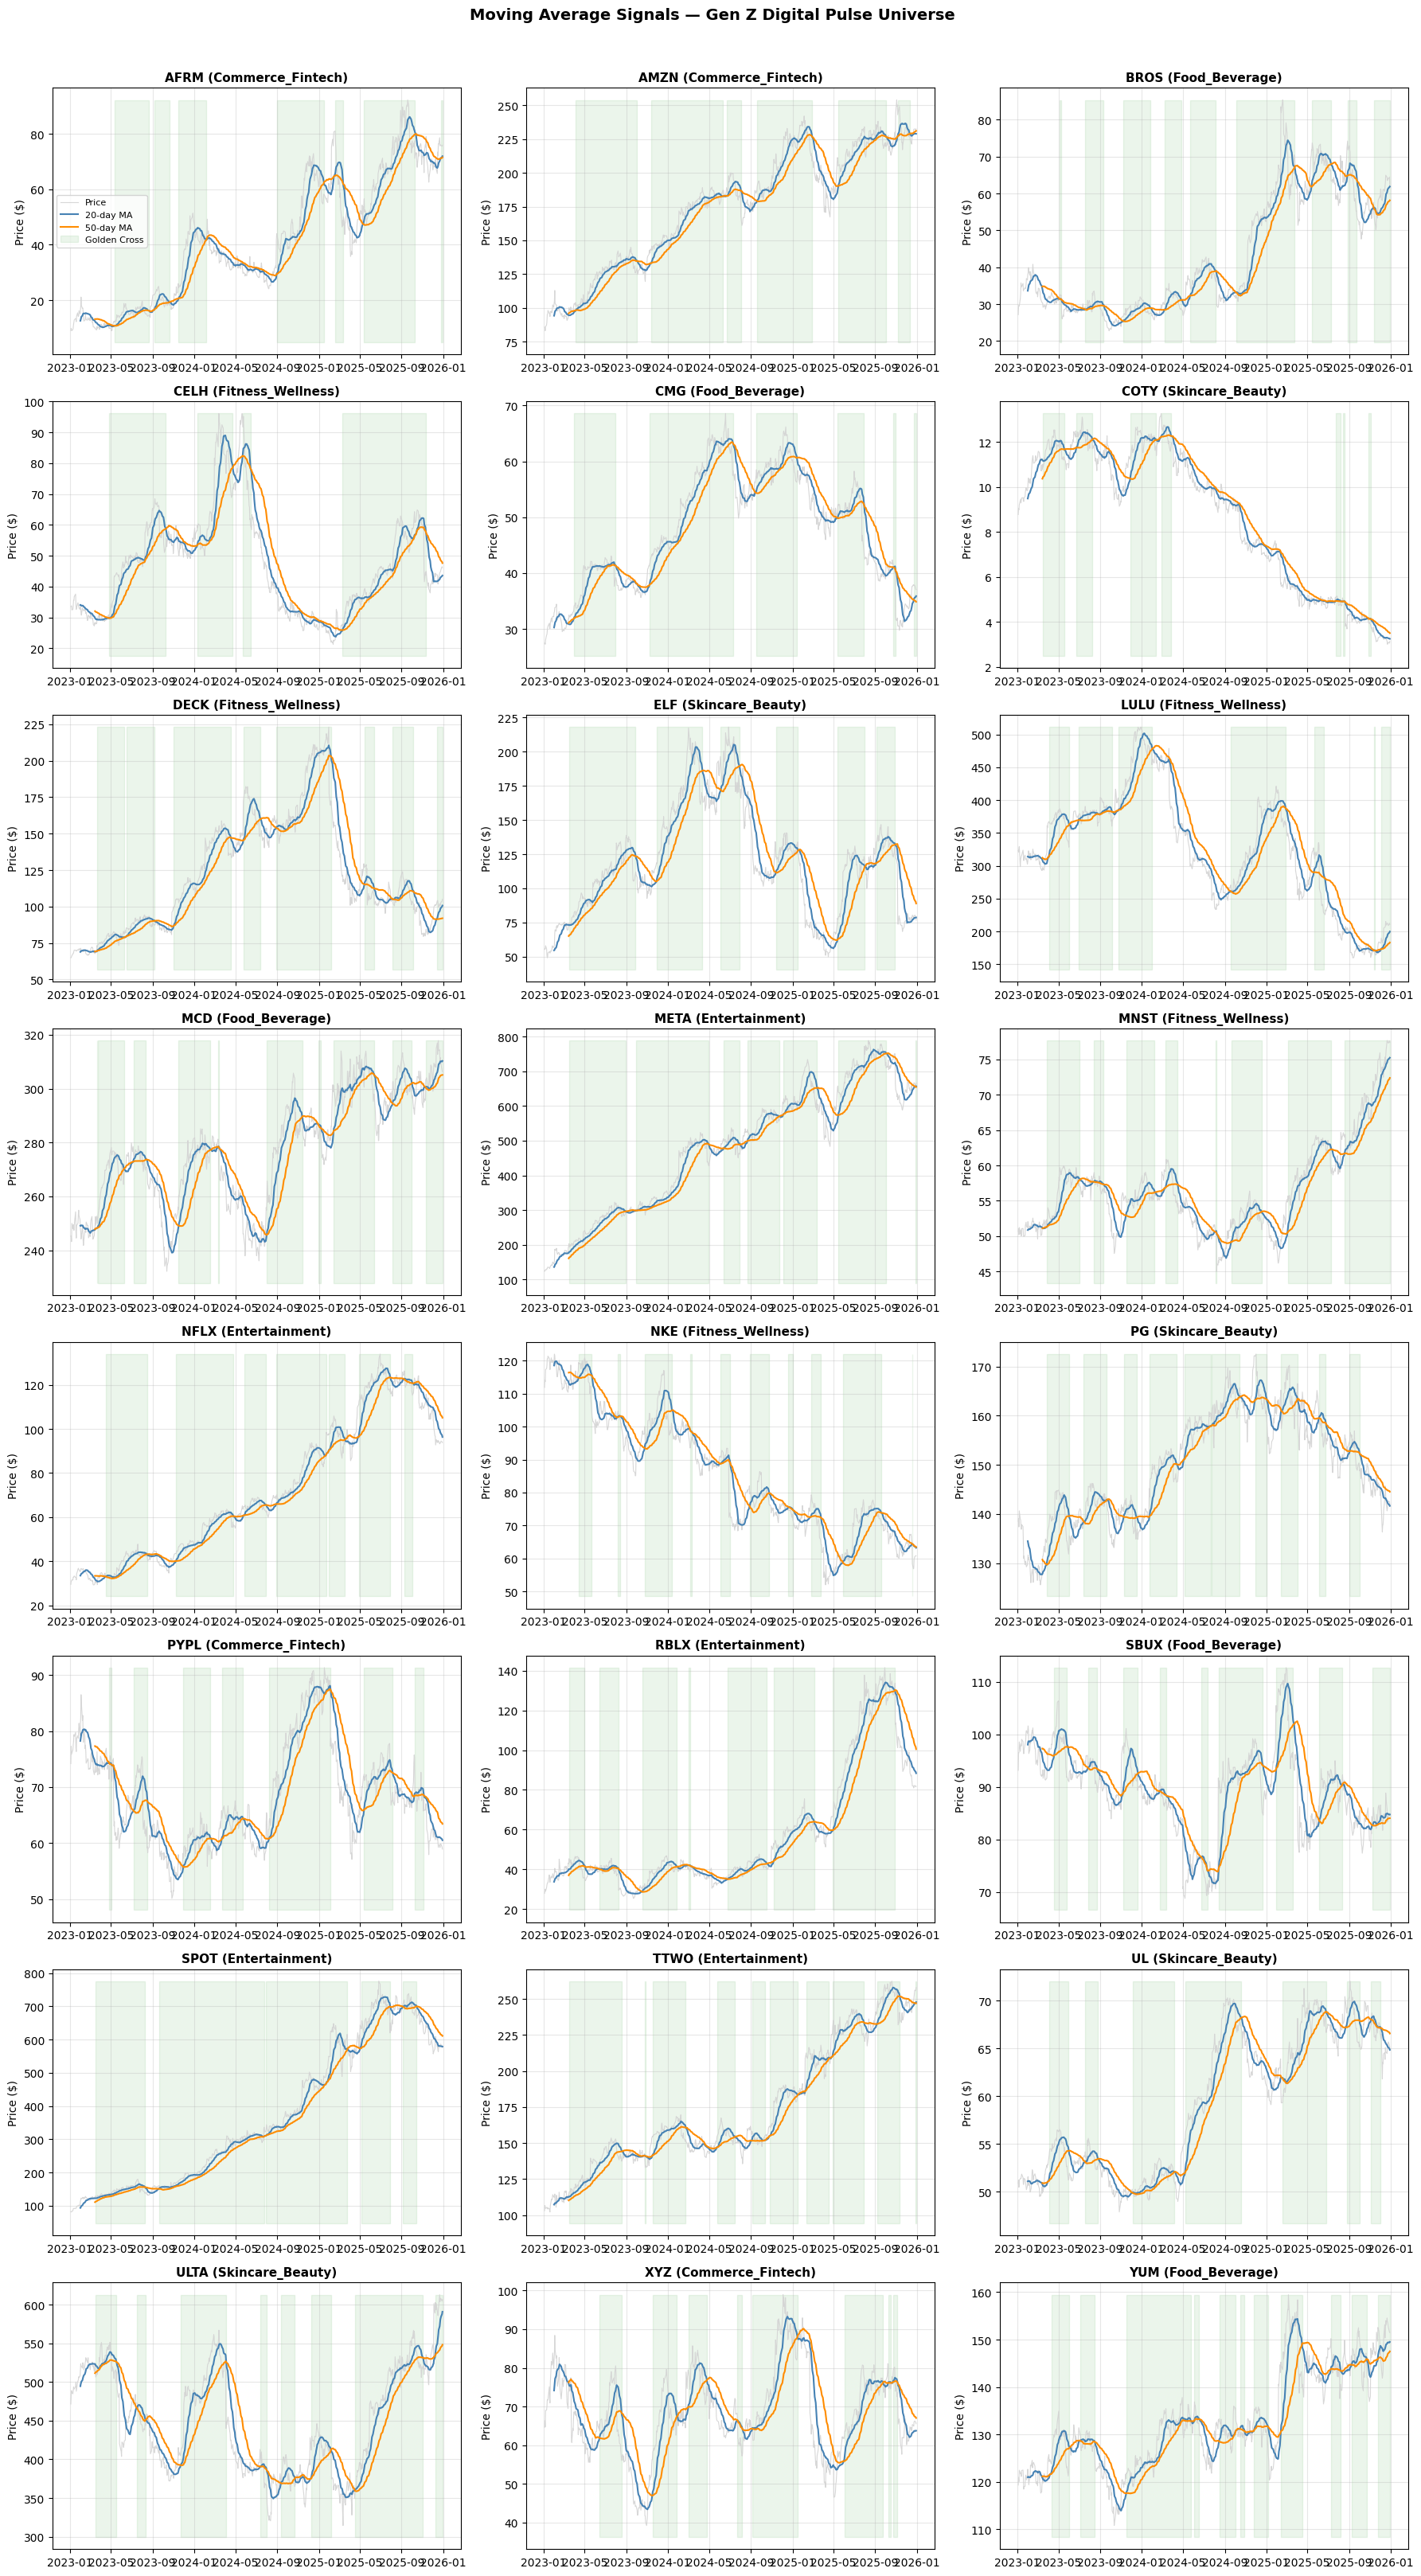

Green shading = Golden Cross period (20-day MA above 50-day MA) = model holds this stock
No shading = Death Cross period = model avoids this stock


In [122]:
# Plot moving averages for every stock in the universe
# This shows visually when Golden Cross and Death Cross events occurred

n_stocks = len(available_tickers)
n_cols   = 3
n_rows   = (n_stocks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, ticker in enumerate(available_tickers):
    ax = axes[idx]

    # Plot price and both moving averages
    ax.plot(raw_prices.index, raw_prices[ticker],
            color='lightgray', linewidth=0.8, alpha=0.9, label='Price')
    ax.plot(ma_short.index, ma_short[ticker],
            color='steelblue', linewidth=1.5, label=f'{SHORT_WINDOW}-day MA')
    ax.plot(ma_long.index, ma_long[ticker],
            color='darkorange', linewidth=1.5, label=f'{LONG_WINDOW}-day MA')

    # Shade Golden Cross periods (short > long) in green
    golden = signals[ticker].reindex(raw_prices.index).fillna(0)
    ax.fill_between(raw_prices.index, ax.get_ylim()[0], raw_prices[ticker].max(),
                    where=(golden == 1),
                    alpha=0.08, color='green', label='Golden Cross')

    sector = ticker_to_sector.get(ticker, '')
    ax.set_title(f'{ticker} ({sector})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide any unused subplot panels
for idx in range(n_stocks, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Moving Average Signals — Gen Z Digital Pulse Universe',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Green shading = Golden Cross period (20-day MA above 50-day MA) = model holds this stock')
print('No shading = Death Cross period = model avoids this stock')

**These charts show the Golden Cross moving average signals for every stock in our Gen Z universe. The blue line is the 20-day moving average, the orange line is the 50-day, and the green shading marks every period where the strategy was actively holding that stock.
The 50-day lags behind the actual price on purpose — the strategy uses the gap between the fast and slow moving average to generate signals. When blue crosses above orange that's our buy signal. When it crosses back below that's our sell signal.**



## STEP 23 — Simulate the Moving Average Strategy Returns

In [123]:
# Align signals with daily returns
# We use the signal from DAY T to decide what we hold on DAY T+1
# (we can't trade on today's signal until tomorrow's open — avoids lookahead bias)
ma_returns = daily_returns[available_tickers].reindex(signals.index)

# Shift signals by 1 day: today's signal → tomorrow's position
positions = signals.shift(1).fillna(0)

# Equal-weight the stocks that have a Golden Cross signal on any given day
# If 4 stocks show a signal, each gets 25%. If none, we hold cash (0% return).
def ma_daily_return(row_returns, row_positions):
    active = row_positions[row_positions == 1].index.tolist()
    if not active:
        return 0.0   # no signal — hold cash
    weight = 1.0 / len(active)
    return sum(row_returns[t] * weight for t in active if t in row_returns.index)

ma_daily_returns = pd.Series(
    [ma_daily_return(ma_returns.iloc[i], positions.iloc[i])
     for i in range(len(ma_returns))],
    index=ma_returns.index
)

# Cumulative returns
ma_cumret = (1 + ma_daily_returns).cumprod()

print(f'MA strategy simulated over {len(ma_daily_returns)} trading days')
print(f'Average daily return:  {ma_daily_returns.mean():.4%}')
print(f'Daily volatility:      {ma_daily_returns.std():.4%}')
print(f'Total return:          {ma_cumret.iloc[-1] - 1:.2%}')
print(f'Days in market:        {(positions.sum(axis=1) > 0).mean():.1%} of trading days')
print(f'Days holding cash:     {(positions.sum(axis=1) == 0).mean():.1%} of trading days')

MA strategy simulated over 701 trading days
Average daily return:  0.0819%
Daily volatility:      1.2579%
Total return:          67.88%
Days in market:        99.9% of trading days
Days holding cash:     0.1% of trading days


**What just happened?**

We simulated what would happen if we followed the moving average signals every day. On any day where at least one stock shows a Golden Cross, we buy equal weights of all signaling stocks. On days where nothing signals, we sit in cash and earn 0%. The shift(1) is critical — it means we're always using yesterday's signal to decide today's trade, not peeking at today's data.

## STEP 24 — Three-Way Comparison: MPT vs Moving Average vs S&P 500

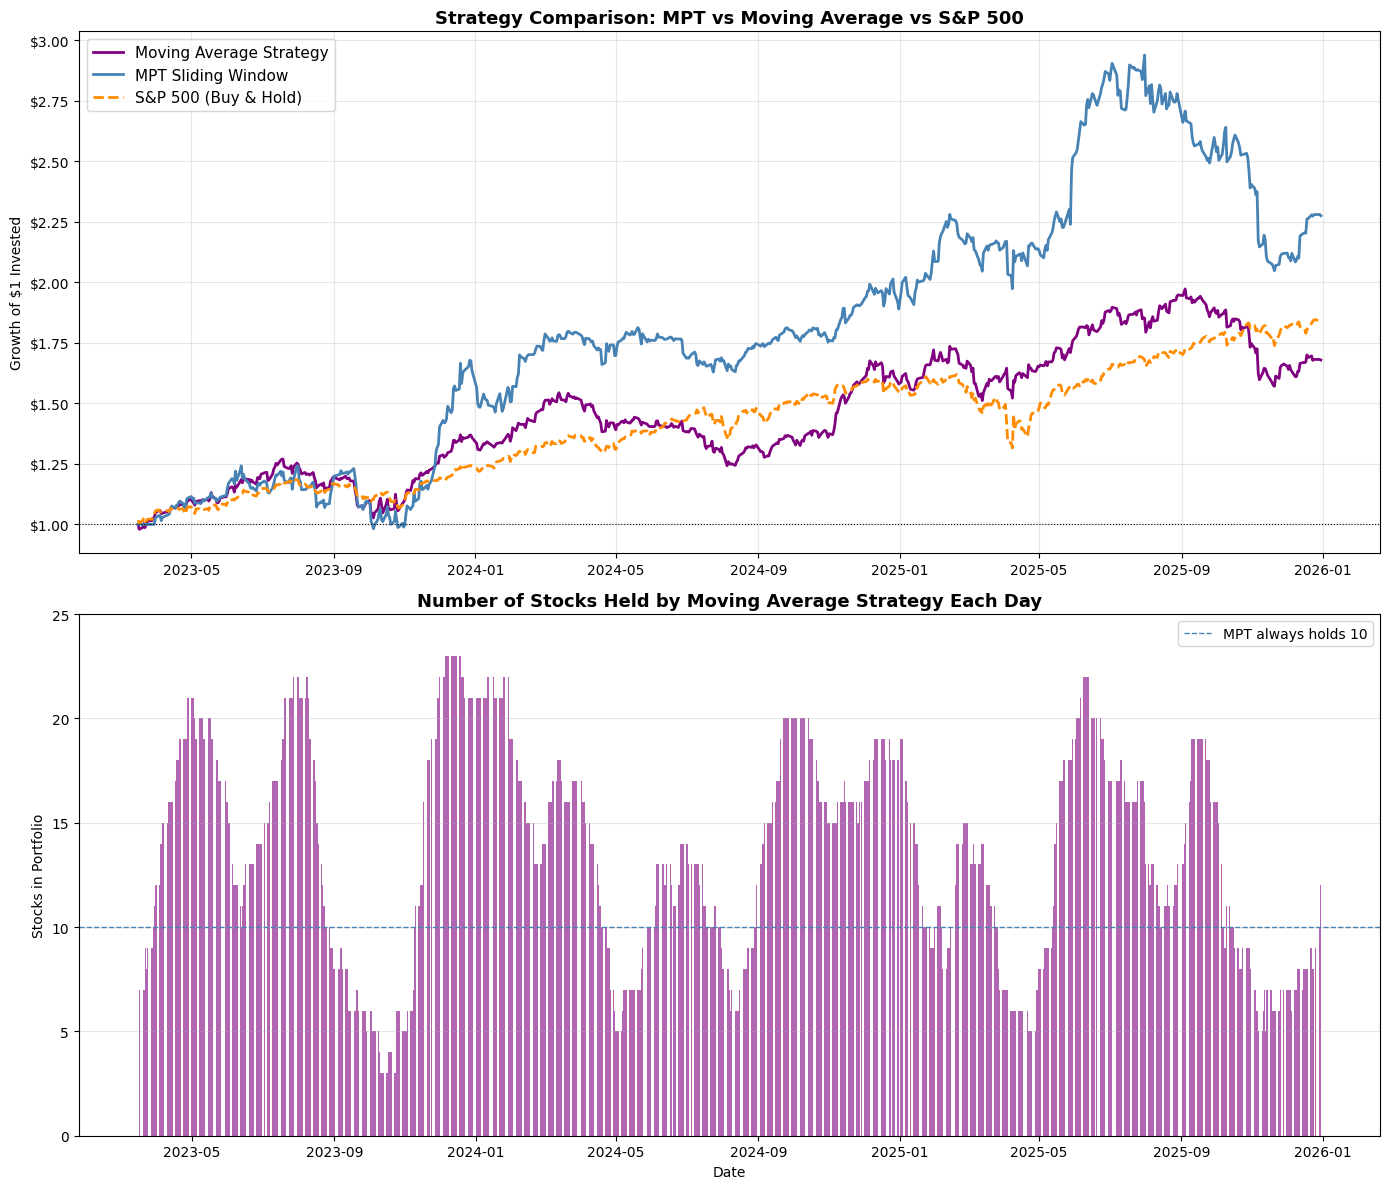

In [124]:
# Align all three strategies to the same date range
# The MA strategy starts later (needs LONG_WINDOW days of warmup)
# so we align everything to the MA start date for a fair comparison
common_start = ma_cumret.index[0]

ma_aligned   = ma_cumret
spy_ma       = (1 + spy_returns.reindex(ma_cumret.index).fillna(0)).cumprod()

# Align MPT results if available
if len(daily_results) > 0:
    mpt_series   = results_df['portfolio_return'].reindex(ma_cumret.index).fillna(0)
    mpt_ma_align = (1 + mpt_series).cumprod()
else:
    mpt_ma_align = None

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Chart 1: Cumulative Return Three-Way ---
axes[0].plot(ma_aligned.index, ma_aligned.values,
             label='Moving Average Strategy', color='purple', linewidth=2)
if mpt_ma_align is not None:
    axes[0].plot(mpt_ma_align.index, mpt_ma_align.values,
                 label='MPT Sliding Window', color='steelblue', linewidth=2)
axes[0].plot(spy_ma.index, spy_ma.values,
             label='S&P 500 (Buy & Hold)', color='darkorange',
             linewidth=2, linestyle='--')
axes[0].set_title('Strategy Comparison: MPT vs Moving Average vs S&P 500',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth of $1 Invested')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='black', linestyle=':', linewidth=0.8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.2f}'))

# --- Chart 2: Number of stocks held each day by MA strategy ---
stocks_held = positions.sum(axis=1).reindex(ma_cumret.index).fillna(0)
axes[1].bar(stocks_held.index, stocks_held.values,
            color='purple', alpha=0.6, width=1)
axes[1].axhline(y=10, color='steelblue', linestyle='--',
                linewidth=1, label='MPT always holds 10')
axes[1].set_title('Number of Stocks Held by Moving Average Strategy Each Day',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Stocks in Portfolio')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, len(available_tickers) + 1)

plt.tight_layout()
plt.show()



**This is the key comparison chart. Three lines, three strategies:
MPT won on return but took more risk to get there. The Moving Average strategy added complexity without beating the simple index fund.**

The bottom chart shows a key structural difference: the MA strategy holds a variable number of stocks (sometimes 0, sometimes all 15), while MPT always holds exactly 10. This chart reveals why the Moving Average strategy couldn't match MPT's returns. On some days it held 23 stocks in equal weights

## STEP 25 — Full Three-Way Performance Summary

In [125]:
# Compute performance metrics for the MA strategy
ma_ret_series  = ma_daily_returns.reindex(ma_cumret.index)
spy_ret_series = spy_returns.reindex(ma_cumret.index).fillna(0)

ma_sharpe = (
    (ma_ret_series.mean() - RF_DAILY) / (ma_ret_series.std() + 1e-10) * np.sqrt(252)
)
spy_sharpe_ma = (
    (spy_ret_series.mean() - RF_DAILY) / (spy_ret_series.std() + 1e-10) * np.sqrt(252)
)

def max_drawdown(cumret):
    rolling_max = cumret.cummax()
    drawdown    = (cumret - rolling_max) / rolling_max
    return drawdown.min()

ma_dd  = max_drawdown(ma_cumret)
spy_dd = max_drawdown(spy_ma)

ma_winrate = (ma_ret_series > 0).mean()

# MPT metrics over the same aligned window (if available)
if mpt_ma_align is not None:
    mpt_ret_aligned = results_df['portfolio_return'].reindex(ma_cumret.index).fillna(0)
    mpt_sharpe_aligned = (
        (mpt_ret_aligned.mean() - RF_DAILY) / (mpt_ret_aligned.std() + 1e-10) * np.sqrt(252)
    )
    mpt_dd_aligned = max_drawdown(mpt_ma_align)
    mpt_total_aligned = mpt_ma_align.iloc[-1] - 1
    mpt_winrate = (mpt_ret_aligned > 0).mean()
else:
    mpt_sharpe_aligned = mpt_dd_aligned = mpt_total_aligned = mpt_winrate = float('nan')

print('=' * 70)
print('         FULL STRATEGY COMPARISON (aligned date range)')
print('=' * 70)
print(f'{"Metric":<30} {"MPT Model":>12} {"Moving Avg":>12} {"S&P 500":>12}')
print('-' * 70)
print(f'{"Total Return":<30} {mpt_total_aligned:>12.2%} {ma_cumret.iloc[-1]-1:>12.2%} {spy_ma.iloc[-1]-1:>12.2%}')
print(f'{"Annualized Sharpe":<30} {mpt_sharpe_aligned:>12.2f} {ma_sharpe:>12.2f} {spy_sharpe_ma:>12.2f}')
print(f'{"Max Drawdown":<30} {mpt_dd_aligned:>12.2%} {ma_dd:>12.2%} {spy_dd:>12.2%}')
print(f'{"Daily Volatility":<30} {mpt_ret_aligned.std():>12.4%} {ma_ret_series.std():>12.4%} {spy_ret_series.std():>12.4%}')
print(f'{"Win Rate":<30} {mpt_winrate:>12.2%} {ma_winrate:>12.2%} {"N/A":>12}')
print(f'{"Avg Stocks Held":<30} {"10 (always)":>12} {stocks_held.mean():>12.1f} {"500 (index)":>12}')
print('=' * 70)

print('\nINTERPRETATION:')
strategies = {
    'MPT Model':      mpt_sharpe_aligned,
    'Moving Average': ma_sharpe,
    'S&P 500':        spy_sharpe_ma
}
best = max(strategies, key=strategies.get)
print(f'  Best risk-adjusted strategy (Sharpe): {best}')
print(f'  MPT vs MA total return difference:    {mpt_total_aligned - (ma_cumret.iloc[-1]-1):+.2%}')
print(f'  MPT vs S&P total return difference:   {mpt_total_aligned - (spy_ma.iloc[-1]-1):+.2%}')
print(f'\n  The Moving Average strategy was in the market {(stocks_held > 0).mean():.1%} of days.')
print(f'  It held cash {(stocks_held == 0).mean():.1%} of days — providing downside protection but missing gains.')

         FULL STRATEGY COMPARISON (aligned date range)
Metric                            MPT Model   Moving Avg      S&P 500
----------------------------------------------------------------------
Total Return                        127.49%       67.88%       83.59%
Annualized Sharpe                      1.03         0.78         1.18
Max Drawdown                        -30.32%      -20.38%      -18.76%
Daily Volatility                    1.7412%      1.2579%      0.9608%
Win Rate                             54.78%       54.49%          N/A
Avg Stocks Held                 10 (always)         13.5  500 (index)

INTERPRETATION:
  Best risk-adjusted strategy (Sharpe): S&P 500
  MPT vs MA total return difference:    +59.61%
  MPT vs S&P total return difference:   +43.90%

  The Moving Average strategy was in the market 99.9% of days.
  It held cash 0.1% of days — providing downside protection but missing gains.


**MPT won on total return but the S&P 500 won on risk-adjusted return. The Moving Average strategy failed to beat either — it added complexity without adding enough value to justify it. The real finding here is that a concentrated, optimized Gen Z portfolio can generate strong absolute returns, but investors pay for that with significantly higher volatility and drawdown risk.**


##Final Summary

In [129]:
print('=' * 62)
print('           COMPLETE PROJECT SUMMARY')
print('=' * 62)
print(f"""
STOCK UNIVERSE: Gen Z Digital Pulse (Digital Pulse Strategy 1)
  22 consumer-facing stocks across 5 sectors
  Selection method: Piper Sandler survey + Google Trends +
                    SEC filing revenue growth verification

WHAT WE BUILT:
  Model 1 — MPT Mixed-Integer Nonlinear Optimizer:
  • Selects exactly {NUM_STOCKS} stocks from a pool of {len(available_tickers)}
  • Enforces sector diversification across {len(sector_map_clean)} sectors
  • Uses binary Y + continuous X variables with linking constraints
  • Builds efficient frontier, auto-selects max Sharpe daily
  • Re-optimizes using a {WINDOW_SIZE}-day sliding window

  Model 2 — Golden Cross Moving Average Strategy:
  • {SHORT_WINDOW}-day MA vs {LONG_WINDOW}-day MA signal
  • Golden Cross = buy signal, Death Cross = exit to cash
  • Equal-weight all signaling stocks each day
  • Variable allocation: 0 to {len(available_tickers)} stocks at any time

CONSTRAINTS IMPLEMENTED (MPT Model):
  ✓ Budget constraint        (proportions sum to 1)
  ✓ Project selection        (exactly {NUM_STOCKS} stocks chosen)
  ✓ Linking constraints      (binary Y coupled to continuous X)
  ✓ Min weight per stock     ({MIN_WEIGHT:.0%} if selected)
  ✓ Max weight per stock     ({MAX_WEIGHT:.0%} if selected)
  ✓ Sector diversification   (at least 1 per sector)
  ✓ Risk ceiling             (quadratic covariance expression)

RESULTS SUMMARY:
  MPT Total Return:           {port_total:.2%}
  MPT Sharpe (annual):        {port_sharpe_annual:.2f}
  Moving Average Sharpe:      {ma_sharpe:.2f}
  S&P 500 Sharpe:             {spy_sharpe_ma:.2f}
  Best strategy by Sharpe:    {best}
""")
print('=' * 62)

           COMPLETE PROJECT SUMMARY

STOCK UNIVERSE: Gen Z Digital Pulse (Digital Pulse Strategy 1)
  22 consumer-facing stocks across 5 sectors
  Selection method: Piper Sandler survey + Google Trends +
                    SEC filing revenue growth verification

WHAT WE BUILT:
  Model 1 — MPT Mixed-Integer Nonlinear Optimizer:
  • Selects exactly 10 stocks from a pool of 24
  • Enforces sector diversification across 5 sectors
  • Uses binary Y + continuous X variables with linking constraints
  • Builds efficient frontier, auto-selects max Sharpe daily
  • Re-optimizes using a 60-day sliding window

  Model 2 — Golden Cross Moving Average Strategy:
  • 20-day MA vs 50-day MA signal
  • Golden Cross = buy signal, Death Cross = exit to cash
  • Equal-weight all signaling stocks each day
  • Variable allocation: 0 to 24 stocks at any time

CONSTRAINTS IMPLEMENTED (MPT Model):
  ✓ Budget constraint        (proportions sum to 1)
  ✓ Project selection        (exactly 10 stocks chosen)
  ✓ L

## STEP 26 — GitHub

When we move this to GitHub Actions, we need the model to save its outputs
as files rather than just displaying them on screen. This step practices that.

We save:
- A CSV of all daily results (the raw data)
- The performance chart as a PNG image
- A summary text file

In production, GitHub Actions will commit these files back to your repo automatically.

In [130]:
import os

# Create a results folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# --- Save 1: Results CSV ---
# Drop the allocations column (it's a dict — hard to store in CSV)
results_to_save = results_df.drop(columns=['allocations'])
results_to_save.to_csv('results/portfolio_results.csv')
print('Saved: results/portfolio_results.csv')

# --- Save 2: Performance comparison chart ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(port_aligned.index, port_aligned.values,
             label='Sliding Window MPT', color='steelblue', linewidth=2)
axes[0].plot(spy_cumret.index, spy_cumret.values,
             label='S&P 500 (Buy & Hold)', color='darkorange',
             linewidth=2, linestyle='--')
axes[0].set_title(f'Portfolio Performance vs S&P 500 (as of {pd.Timestamp.now().strftime("%Y-%m-%d")})',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth of $1 Invested')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='black', linestyle=':', linewidth=0.8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.2f}'))

axes[1].bar(results_df.index,
            results_df['portfolio_return'],
            color=['steelblue' if r >= 0 else 'tomato'
                   for r in results_df['portfolio_return']],
            alpha=0.7, width=1)
axes[1].set_title('Daily Returns', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: results/performance_comparison.png')

# --- Save 3: Summary text file ---
summary_text = f"""PORTFOLIO OPTIMIZATION SUMMARY
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
Date range: {results_df.index[0].date()} to {results_df.index[-1].date()}

PERFORMANCE vs S&P 500
{'='*40}
{'Metric':<28} {'MPT':>8} {'S&P500':>8}
{'-'*40}
{'Total Return':<28} {port_aligned.iloc[-1]-1:>8.2%} {spy_cumret.iloc[-1]-1:>8.2%}
{'Annualized Sharpe':<28} {port_sharpe_annual:>8.2f} {spy_sharpe_annual:>8.2f}
{'Max Drawdown':<28} {port_dd:>8.2%} {spy_dd:>8.2%}
{'Win Rate':<28} {win_rate:>8.2%} {'N/A':>8}
{'Trading Days':<28} {len(port_ret_series):>8} {len(spy_ret_series):>8}

MODEL SETTINGS
{'='*40}
Stocks in pool:   {len(available_tickers)}
Stocks selected:  {NUM_STOCKS}
Window size:      {WINDOW_SIZE} days
Min weight:       {MIN_WEIGHT:.0%}
Max weight:       {MAX_WEIGHT:.0%}
Sectors covered:  {len(sector_map_clean)}
"""

with open('results/summary.txt', 'w') as f:
    f.write(summary_text)
print('Saved: results/summary.txt')

print('\nAll results saved to the results/ folder.')
print('These are the files GitHub Actions will commit back to your repo.')

Saved: results/portfolio_results.csv
Saved: results/performance_comparison.png
Saved: results/summary.txt

All results saved to the results/ folder.
These are the files GitHub Actions will commit back to your repo.
